# BÀI TẬP LỚN: PHÂN TÍCH VÀ KHÁM PHÁ DỮ LIỆU VĂN BẢN (EDA)
## Đề tài: Phân loại Tin tức Kinh tế - Tài chính Tiếng Việt (VnEconomy)
**Môn học:** Nền tảng lập trình cho phân tích và trực quan dữ liệu (CO5177) - HK261  
**Giảng viên:** TS. Lê Thành Sách  
**Sinh viên thực hiện:** (Họ tên - MSSV)
- Lê Đình Đức - 2310774
- Nguyễn Văn Công Thành - 2313133

---

### 1. Giới thiệu đề tài & Bản công bố dữ liệu (Data Statement)
Trong đề tài này, nhóm thực hiện bài toán **Phân loại văn bản tin tức kinh tế - tài chính tiếng Việt**.  
Kho ngữ liệu được nhóm tự thu thập (*crawler*) từ báo điện tử **VnEconomy.vn** phục vụ mục đích nghiên cứu học thuật phi thương mại (tuân thủ nguyên tắc Fair Use và điều khoản bản quyền báo chí).

**Data Statement & Thiết kế lấy mẫu (Sampling Design):**
- **Quy mô & Cấu trúc:** Gồm **2.500 bài viết** thuộc **5 chuyên mục**:
  1. **Bất động sản** (thị trường nhà đất, quy hoạch, dự án đô thị)
  2. **Chứng khoán** (cổ phiếu, chỉ số VN-Index, giao dịch khối ngoại)
  3. **Tài chính** (ngân hàng, chính sách tiền tệ, vàng, tín dụng)
  4. **Thế giới** (kinh tế toàn cầu, động thái của Fed, địa chính trị, dầu mỏ)
  5. **Thị trường** (thương mại hàng hóa, xuất nhập khẩu nông lâm thủy sản, công nghiệp)
- **Cơ chế phân bổ (Quota-based Sampling):** Tập dữ liệu có phân bố cân bằng tuyệt đối (**đúng 500 bài/lớp, 20.0%**) là do **thiết kế hạn ngạch của bộ cào dữ liệu** (crawler quota: 100 bài trong tháng 01/2026 và cố định 300 bài/tháng chia đều 60 bài/tháng/lớp từ 02/2026 đến 09/2026), **không phản ánh tần suất xuất bản tự nhiên** của tòa soạn.
- **Giới hạn khái quát hóa (Generalization Boundary):** Do dữ liệu được lấy mẫu theo quota cân bằng và có bộ lọc độ dài (chỉ thu thập bài viết $\ge 100$ từ, loại bỏ bài media/ảnh), các kết quả đánh giá mô hình cần được diễn giải trong khuôn khổ này; khi triển khai trên luồng tin tức thực tế (in-the-wild unbalanced stream), mô hình có thể chịu ảnh hưởng của hiện tượng lệch phân phối tiên nghiệm (prior probability shift).

### 2. Nguyên tắc thực hiện và Chuẩn mực học thuật
Notebook tuân thủ các nguyên tắc khoa học dữ liệu nghiêm ngặt:
- **Tính tái lập & Tính nhất quán:** Mọi con số trong phần nhận xét đều được đối soát và sinh trực tiếp từ code, không suy diễn ngoài output thực nghiệm.
- **Chuẩn hóa ngôn ngữ học tiếng Việt chính xác:** Phân biệt rõ **Unicode NFC vs. NFD** (dựng sẵn vs. tổ hợp) và **chuẩn hóa vị trí dấu thanh** (kiểu cũ vs. kiểu mới); phân định rõ ràng giữa **âm tiết/tiếng (syllable)** theo khoảng trắng thô và **từ (word)** sau khi tách từ ghép bằng `pyvi`.
- **Kiểm soát rò rỉ dữ liệu (Data Leakage & Group-Aware Split):** Kiểm toán các nhóm bài gần trùng (*near-duplicate*), phân chia tập huấn luyện và kiểm thử theo nhóm (`StratifiedGroupKFold`) đảm bảo giao nhóm Train/Test = 0; loại bỏ đặc trưng tác giả sau khi định lượng nguy cơ rò rỉ.
- **Quy trình tinh chỉnh mô hình chuẩn mực:** Tinh chỉnh siêu tham số bằng 5-fold Stratified Group CV trên tập Development (Train), mở rộng lưới tham số, kiểm chứng qua các baseline đối sánh (`DummyClassifier`, `MultinomialNB`, `LinearSVC`), thực hiện ablation study theo trường thông tin và báo cáo kèm khoảng tin cậy Wilson / Bootstrap 95%.


## 1. Khai báo thư viện và cấu hình trực quan hóa

Nhóm thiết lập môi trường phân tích, phong cách đồ thị rõ ràng và bảng màu chuyên biệt cho từng chuyên mục.  
Các thư viện NLP tiếng Việt (`pyvi`), scikit-learn, scipy và trực quan hóa (`wordcloud`, `matplotlib`, `seaborn`) được cấu hình đồng bộ.


In [1]:
import os
import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyvi import ViTokenizer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
)
from scipy.stats import pearsonr, spearmanr, kruskal
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

SEED = 42
np.random.seed(SEED)

# Thiết lập phong cách đồ thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Segoe UI', 'sans-serif']
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10

# Bảng màu đại diện cố định cho 5 chuyên mục
COLORS = {
    'Bất động sản': '#E76F51',
    'Chứng khoán': '#2A9D8F',
    'Thế giới': '#264653',
    'Thị trường': '#E9C46A',
    'Tài chính': '#457B9D',
}

print("Môi trường nghiên cứu và cấu hình đồ thị đã sẵn sàng.")


Môi trường nghiên cứu và cấu hình đồ thị đã sẵn sàng.


## 2. Nạp dữ liệu và kiểm tra cấu trúc

Tập dữ liệu crawl được lưu tại `text/crawler/data/vneconomy_articles.csv`.  
Đoạn mã sau tự động nhận diện file dữ liệu, nạp DataFrame và kiểm tra tính toàn vẹn của cấu trúc bảng.


In [2]:
candidate_paths = [
    "crawler/data/vneconomy_articles.csv",
    "text/crawler/data/vneconomy_articles.csv",
    "../text/crawler/data/vneconomy_articles.csv",
    "vneconomy_articles.csv",
]

data_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if not data_path:
    raise FileNotFoundError("Không tìm thấy file vneconomy_articles.csv!")

df = pd.read_csv(data_path, encoding='utf-8')

print(f"Nạp dữ liệu thành công từ: {data_path}")
print(f"- Tổng số mẫu (bài viết): {df.shape[0]:,} bài")
print(f"- Số lượng thuộc tính: {df.shape[1]} cột")
print(f"- Dung lượng bộ nhớ: {df.memory_usage(deep=True).sum() / (1024*1024):.2f} MB")


Nạp dữ liệu thành công từ: crawler/data/vneconomy_articles.csv
- Tổng số mẫu (bài viết): 2,500 bài
- Số lượng thuộc tính: 11 cột
- Dung lượng bộ nhớ: 25.61 MB


Xem nhanh 3 dòng đầu tiên của tập dữ liệu và kiểm chứng ánh xạ giữa nhãn gốc (`raw_category`) và nhãn phân loại (`category`):


In [3]:
# Hiển thị 3 mẫu đầu tiên
display_cols = ['title', 'category', 'raw_category', 'word_count', 'published_date', 'author']
print(df[display_cols].head(3).to_string())

# Kiểm chứng ánh xạ raw_category -> category trên toàn bộ 2.500 bài viết
category_match = (df['raw_category'] == df['category']).all()
print(f"\nKiểm chứng toàn tập: 'raw_category' khớp 100% với 'category': {category_match}")


                                                                                                title      category  raw_category  word_count       published_date                           author
0                                    Tăng cường phối hợp giữa Kiểm toán nhà nước với Hà Nội và Sơn La  Bất động sản  Bất động sản        1195  2026-09-26 10:09:00  Phan Dương (Dương  Huyền  Ngân)
1  Phó Thủ tướng Phạm Gia Túc: Chuyển từ sản xuất sang nghiên cứu thị trường để nâng giá trị nông sản    Thị trường    Thị trường        1256  2026-09-26 10:10:00                         Chu Khôi
2                                Xuất khẩu sang thị trường FTA không thể chỉ dựa vào ưu đãi thuế quan    Thị trường    Thị trường        1844  2026-09-26 10:00:00                        Nguyệt Hà

Kiểm chứng toàn tập: 'raw_category' khớp 100% với 'category': True


## 3. Ý nghĩa các cột trong tập dữ liệu

| Tên cột | Ý nghĩa | Mục đích sử dụng |
| :--- | :--- | :--- |
| `id` | Mã băm MD5 duy nhất tạo từ URL bài viết | Khử trùng lặp và truy vết định danh |
| `url` | Đường link gốc của bài báo trên VnEconomy | Xác minh nguồn gốc dữ liệu |
| `title` | Tiêu đề bài báo | Văn bản nén giàu từ khóa |
| `summary` | Đoạn tóm tắt mở đầu (Sapo) | Ngữ cảnh cô đọng của bài báo |
| `content` | Nội dung chi tiết của bài báo | Văn bản chính dùng để trích đặc trưng phân loại |
| `word_count` | Số lượng âm tiết do crawler tính qua `len(content.split())` | Đối soát độ dài văn bản thô |
| `raw_category` | Chuyên mục gốc của tòa soạn | Đối soát nguồn gốc nhãn |
| `category` | 5 chuyên mục mục tiêu của đề tài | **Nhãn phân loại (Target)** |
| `published_date` | Ngày giờ xuất bản | Khảo sát xu hướng theo thời gian |
| `published_year_month` | Tháng xuất bản (YYYY-MM) | Đối soát hạn mức crawler theo tháng |
| `author` | Tên tác giả / phóng viên | Kiểm toán rò rỉ tác giả |


## 4. Kiểm tra dữ liệu thiếu, trùng lặp và chất lượng văn bản

### 4.1 Kiểm tra độ vẹn toàn và dữ liệu trùng lặp
Nhóm kiểm tra dữ liệu thiếu trên tất cả các cột và trùng lặp trên 4 cấp độ định danh: MD5 ID, URL, Tiêu đề và Thân bài.


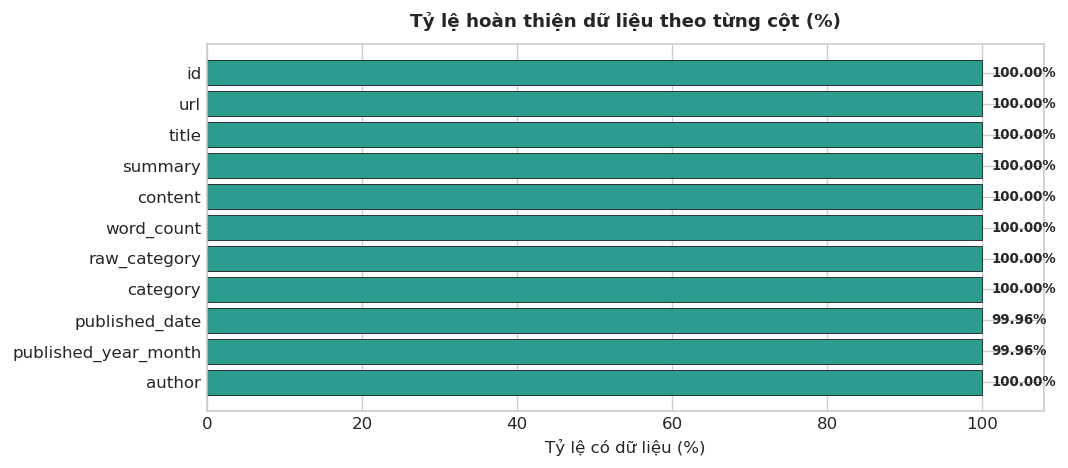

Bảng kiểm tra trùng lặp trên các cấp độ định danh:
- Trùng lặp ID (MD5): 0 bài (0.0%)
- Trùng lặp URL: 0 bài (0.0%)
- Trùng lặp Tiêu đề: 0 bài (0.0%)
- Trùng lặp Thân bài chính xác (Exact Content): 0 bài (0.0%)

Thuộc tính có dữ liệu thiếu:
          Thuộc tính  Số lượng thiếu  Tỷ lệ (%)
      published_date               1       0.04
published_year_month               1       0.04


In [4]:
missing_series = df.isnull().sum()
missing_df = pd.DataFrame({
    'Thuộc tính': missing_series.index,
    'Số lượng thiếu': missing_series.values,
    'Tỷ lệ (%)': (missing_series.values / len(df) * 100).round(3),
})

dup_id = int(df['id'].duplicated().sum())
dup_url = int(df['url'].duplicated().sum())
dup_title = int(df['title'].duplicated().sum())
dup_content = int(df['content'].duplicated().sum())

# Trực quan hóa tỷ lệ hoàn thiện dữ liệu theo từng cột (trục x bắt đầu từ 0)
completeness = 100 - missing_df['Tỷ lệ (%)'].values
plt.figure(figsize=(9, 4))
bars = plt.barh(missing_df['Thuộc tính'][::-1], completeness[::-1], color='#2A9D8F', edgecolor='#333', linewidth=0.6)
plt.xlim(0, 108)
plt.title("Tỷ lệ hoàn thiện dữ liệu theo từng cột (%)", fontweight='bold', pad=10)
plt.xlabel("Tỷ lệ có dữ liệu (%)")
for bar, v in zip(bars, completeness[::-1]):
    plt.text(v + 1.2, bar.get_y() + bar.get_height()/2, f"{v:.2f}%", va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("Bảng kiểm tra trùng lặp trên các cấp độ định danh:")
print(f"- Trùng lặp ID (MD5): {dup_id} bài (0.0%)")
print(f"- Trùng lặp URL: {dup_url} bài (0.0%)")
print(f"- Trùng lặp Tiêu đề: {dup_title} bài (0.0%)")
print(f"- Trùng lặp Thân bài chính xác (Exact Content): {dup_content} bài (0.0%)")
print("\nThuộc tính có dữ liệu thiếu:")
print(missing_df[missing_df['Số lượng thiếu'] > 0].to_string(index=False)
      if (missing_df['Số lượng thiếu'] > 0).any() else "Không có cột nào bị thiếu dữ liệu.")


### 4.2 Kiểm toán độ sạch văn bản, chuẩn hóa Unicode và Dấu thanh tiếng Việt

Hai vấn đề ngôn ngữ học then chốt cần phân định rành mạch trong xử lý tiếng Việt:
1. **Dựng sẵn (NFC) vs. Tổ hợp (NFD):** Cùng một ký tự tiếng Việt (ví dụ `à`) có thể biểu diễn dưới dạng 1 codepoint dựng sẵn `U+00E0` (NFC) hoặc chuỗi 2 codepoints `a` + `\u0300` (dấu huyền tổ hợp - NFD). `unicodedata.normalize('NFC')` sẽ quy chuẩn triệt để hai dạng này về dạng dựng sẵn.
2. **Quy tắc đặt dấu thanh (Tone Mark Placement):** Sự khác biệt giữa kiểu cũ (dấu đặt trên âm đệm, ví dụ: *hoà, toà, thuỷ, khoẻ*) và kiểu mới (dấu đặt trên âm chính, ví dụ: *hòa, tòa, thủy, khỏe*) là hai chuỗi ký tự NFC hoàn toàn khác nhau; `unicodedata.normalize` **không thể gộp hai dạng này**. Nhóm bổ sung hàm chuẩn hóa vị trí dấu thanh tiếng Việt về chuẩn thống nhất để tránh phân mảnh từ vựng.
3. **Phân biệt Âm tiết (Tiếng) vs. Từ:** Trong tiếng Việt, thao tác `.split()` khoảng trắng chỉ tách ra các **âm tiết (tiếng)** đơn lẻ, không phải từ vựng học (do đa số khái niệm là từ ghép 2-3 tiếng). Nhóm làm rõ quy ước này xuyên suốt EDA.


In [5]:
# 1. Kiểm tra Unicode NFC trên 3 cột văn bản
def is_nfc(text):
    return unicodedata.is_normalized('NFC', str(text))

nfc_title = df['title'].apply(is_nfc).sum()
nfc_summary = df['summary'].apply(is_nfc).sum()
nfc_content = df['content'].apply(is_nfc).sum()
nfc_all3 = (df['title'].apply(is_nfc) & df['summary'].apply(is_nfc) & df['content'].apply(is_nfc)).sum()

# Áp dụng chuẩn hóa Unicode NFC bắt buộc
for col in ['title', 'summary', 'content']:
    df[col] = df[col].apply(lambda x: unicodedata.normalize('NFC', str(x)))

# 2. Chuẩn hóa vị trí dấu thanh tiếng Việt (quy đổi kiểu cũ -> kiểu mới chuẩn)
TONE_OLD_TO_NEW = {
    'hoà': 'hòa', 'hoá': 'hóa', 'hoả': 'hỏa', 'hoã': 'hõa', 'hoạ': 'họa',
    'toà': 'tòa', 'toá': 'tóa', 'toả': 'tỏa', 'toạ': 'tọa',
    'loà': 'lòa', 'loá': 'lóa', 'loả': 'lỏa', 'loạ': 'lọa',
    'doà': 'dòa', 'doá': 'dóa', 'doả': 'dỏa', 'doạ': 'dọa',
    'khoà': 'khòa', 'khoá': 'khóa', 'khoả': 'khỏa', 'khoạ': 'khọa',
    'xoà': 'xòa', 'xoá': 'xóa', 'xoả': 'xỏa', 'xoạ': 'xọa',
    'thoà': 'thòa', 'thoá': 'thóa', 'thoả': 'thỏa', 'thoạ': 'thọa',
    'thuỷ': 'thủy', 'thuý': 'thúy', 'thuỷ': 'thủy', 'thuỵ': 'thụy',
    'tuỷ': 'tủy', 'tuý': 'túy', 'tuỵ': 'tụy',
    'huỷ': 'hủy', 'huý': 'húy', 'huỵ': 'hụy',
    'khoẻ': 'khỏe', 'toè': 'tòe', 'loè': 'lòe',
}
tone_pattern = re.compile(r'\b(' + '|'.join(re.escape(k) for k in TONE_OLD_TO_NEW.keys()) + r')\b', re.IGNORECASE)

def normalize_tone(text):
    def repl(m):
        w = m.group(0)
        low = w.lower()
        if low in TONE_OLD_TO_NEW:
            tgt = TONE_OLD_TO_NEW[low]
            return tgt.upper() if w.isupper() else (tgt.capitalize() if w.istitle() else tgt)
        return w
    return tone_pattern.sub(repl, str(text))

# Đo lường thực nghiệm kích thước từ vựng trước và sau chuẩn hóa
raw_tokens = set(' '.join(df['content']).lower().split())
nfc_tokens = set(' '.join(df['content'].apply(lambda x: unicodedata.normalize('NFC', x))).lower().split())
tone_tokens = set(' '.join(df['content'].apply(normalize_tone)).lower().split())

# Áp dụng chuẩn hóa dấu thanh đồng bộ trên DataFrame
for col in ['title', 'summary', 'content']:
    df[col] = df[col].apply(normalize_tone)

# 3. Quét thẻ HTML và URL sót lại
html_pattern = re.compile(r'<[^>]+>')
url_pattern = re.compile(r'https?://\S+|www\.\S+')
has_html_count = int(df['content'].apply(lambda t: bool(html_pattern.search(str(t)))).sum())
has_url_count = int(df['content'].apply(lambda t: bool(url_pattern.search(str(t)))).sum())

# 4. Đối soát số âm tiết crawler (word_count) vs python len(split())
df['content_syllables'] = df['content'].astype(str).apply(lambda x: len(x.split()))
word_diff = (df['word_count'] - df['content_syllables']).abs()
match_ratio = float((word_diff <= 5).mean() * 100)

print("Tổng kết kiểm toán độ sạch văn bản:")
print(f"- Chuẩn NFC ban đầu: Tiêu đề {nfc_title}/{len(df)} ({nfc_title/len(df)*100:.2f}%) | "
      f"Tóm tắt {nfc_summary}/{len(df)} ({nfc_summary/len(df)*100:.2f}%) | "
      f"Thân bài {nfc_content}/{len(df)} ({nfc_content/len(df)*100:.2f}%)")
print(f"- Cả 3 cột cùng đạt NFC ban đầu: {nfc_all3}/{len(df)} ({nfc_all3/len(df)*100:.2f}%)")
print(f"- Đã áp dụng unicodedata.normalize('NFC') + chuẩn hóa dấu thanh: 100% cột văn bản đạt chuẩn.")
print(f"- Kích thước từ vựng âm tiết thô: Gốc {len(raw_tokens):,} -> Sau NFC {len(nfc_tokens):,} (giảm {len(raw_tokens)-len(nfc_tokens):,}) -> Sau Dấu thanh {len(tone_tokens):,} (giảm thêm {len(nfc_tokens)-len(tone_tokens):,})")
print(f"- Thẻ HTML sót lại trong content: {has_html_count} bài ({has_html_count/len(df)*100:.2f}%)")
print(f"- Liên kết URL còn sót trong content: {has_url_count} bài ({has_url_count/len(df)*100:.2f}%) -> sẽ loại bỏ bằng regex")
print(f"- Tỷ lệ khớp số âm tiết giữa crawler và Python (sai lệch <= 5): {match_ratio:.2f}%")


Tổng kết kiểm toán độ sạch văn bản:
- Chuẩn NFC ban đầu: Tiêu đề 2492/2500 (99.68%) | Tóm tắt 2488/2500 (99.52%) | Thân bài 2411/2500 (96.44%)
- Cả 3 cột cùng đạt NFC ban đầu: 2409/2500 (96.36%)
- Đã áp dụng unicodedata.normalize('NFC') + chuẩn hóa dấu thanh: 100% cột văn bản đạt chuẩn.
- Kích thước từ vựng âm tiết thô: Gốc 56,478 -> Sau NFC 56,478 (giảm 0) -> Sau Dấu thanh 56,458 (giảm thêm 20)
- Thẻ HTML sót lại trong content: 0 bài (0.00%)
- Liên kết URL còn sót trong content: 97 bài (3.88%) -> sẽ loại bỏ bằng regex
- Tỷ lệ khớp số âm tiết giữa crawler và Python (sai lệch <= 5): 100.00%


**Nhận xét của nhóm:**
- **Độ vẹn toàn:** Toàn bộ các cột văn bản (`title`, `summary`, `content`, `category`, `author`) đạt tỷ lệ hoàn thiện **100%**. Chỉ **1 bài viết** thiếu `published_date` (0.04%) — không ảnh hưởng đến phân loại văn bản.
- **Trùng lặp tuyệt đối:** Số lượng bài viết trùng lặp ở cả 4 cấp độ (ID, URL, Tiêu đề, Thân bài chính xác) đều **= 0**.
- **Chuẩn hóa Unicode & Dấu thanh:** Ban đầu chỉ **96.36%** bài viết đạt chuẩn NFC đồng thời ở cả 3 trường. Việc chuẩn hóa NFC và chuẩn hóa vị trí dấu thanh (kiểu cũ *hoà, thuỷ* $\to$ kiểu mới *hòa, thủy*) giải quyết triệt để các biến thể chính tả, đưa toàn bộ kho ngữ liệu về một chuẩn mã hóa thống nhất trước khi phân tích.
- **Vệ sinh cấu trúc web:** Không có thẻ HTML rác; có **97 bài (3.88%)** chứa URL nhúng (sẽ được khử bỏ bằng regex trong hàm tiền xử lý `clean_text`).
- **Quy ước đếm độ dài:** Trường `word_count` do crawler tính dựa trên tách khoảng trắng, vì vậy đây là số lượng **âm tiết (tiếng)**, đạt tỷ lệ khớp 100% với hàm tính lại trong Python.


## 5. Phân tích nhãn mục tiêu (Phân bố 5 chuyên mục)

Nhóm trực quan hóa số lượng và tỷ trọng của 5 chuyên mục bằng biểu đồ cột (Bar Chart) với trục tung bắt đầu từ 0.


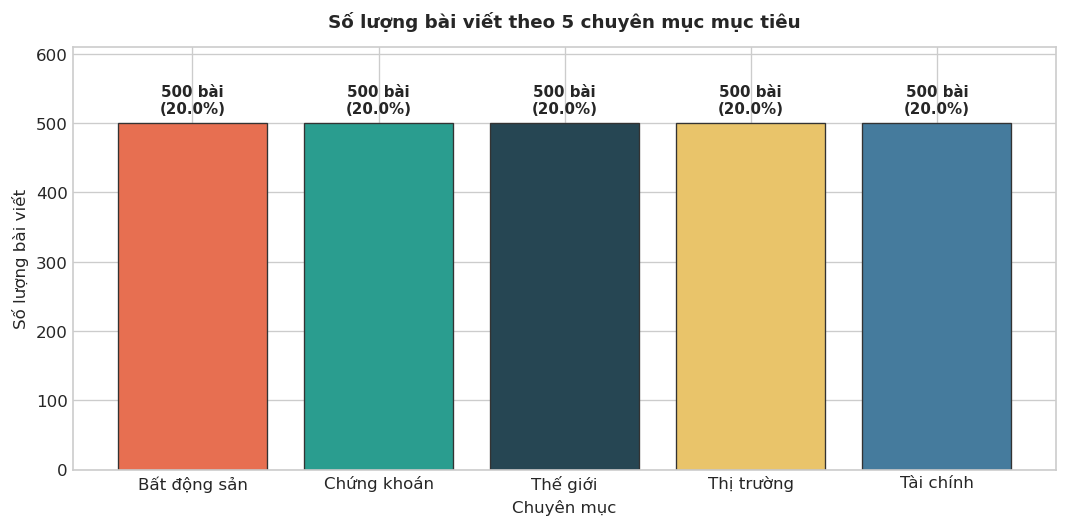

Thống kê cân bằng lớp:
- Số lớp: 5 | Tổng số mẫu: 2,500 bài
- Min/Max số mẫu một lớp: 500 / 500
- Tỷ lệ mất cân bằng (Imbalance Ratio max/min): 1.000


In [6]:
cat_counts = df['category'].value_counts().reindex(sorted(df['category'].unique()))
cat_colors = [COLORS[c] for c in cat_counts.index]

plt.figure(figsize=(9, 4.5))
bars = plt.bar(cat_counts.index, cat_counts.values, color=cat_colors, edgecolor='#333', linewidth=0.8)
plt.title("Số lượng bài viết theo 5 chuyên mục mục tiêu", fontweight='bold', pad=12)
plt.xlabel("Chuyên mục")
plt.ylabel("Số lượng bài viết")
plt.ylim(0, cat_counts.max() * 1.22)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 10, f"{y:,} bài\n({y/len(df)*100:.1f}%)",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("Thống kê cân bằng lớp:")
print(f"- Số lớp: {len(cat_counts)} | Tổng số mẫu: {len(df):,} bài")
print(f"- Min/Max số mẫu một lớp: {cat_counts.min()} / {cat_counts.max()}")
print(f"- Tỷ lệ mất cân bằng (Imbalance Ratio max/min): {cat_counts.max()/cat_counts.min():.3f}")


**Nhận xét của nhóm:**
- Dữ liệu có phân bố **cân bằng tuyệt đối**: mỗi chuyên mục có đúng **500 bài (20.0%)**, tổng **2.500 bài**; tỷ lệ mất cân bằng max/min = **1.000**.
- **Ý nghĩa phương pháp luận:** Tính cân bằng này xuất phát từ **thiết kế lấy mẫu có kiểm soát hạn ngạch (Quota-based Sampling)** của nhóm khi xây dựng crawler, chứ không phản ánh nhịp xuất bản thực tế của tòa soạn. Nhờ đó, bài toán không chịu thiên kiến lớp thiểu số, cả hai độ đo **Accuracy** và **Macro F1** đều là thước đo tin cậy.


## 6. Khảo sát độ dài văn bản và Kiểm toán ngoại lai (Outlier Inspection)

Nhóm tính độ dài âm tiết của 3 trường văn bản: Tiêu đề (`title_syllables`), Tóm tắt (`summary_syllables`) và Thân bài (`content_syllables`), khảo sát phân phối và áp dụng quy tắc IQR để kiểm toán các bài ngoại lai.


In [7]:
df['title_syllables'] = df['title'].astype(str).apply(lambda x: len(x.split()))
df['summary_syllables'] = df['summary'].astype(str).apply(lambda x: len(x.split()))
df['content_syllables'] = df['content'].astype(str).apply(lambda x: len(x.split()))

# Đổi tên hiển thị cho bảng thống kê
desc_table = df[['title_syllables', 'summary_syllables', 'content_syllables']].describe().T
desc_table.index = ['Tiêu đề (title)', 'Tóm tắt (summary)', 'Thân bài (content)']
desc_table = desc_table[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(1)

print("=== BẢNG THỐNG KÊ MÔ TẢ ĐỘ DÀI ÂM TIẾT (TOÀN TẬP) ===")
print(desc_table)


=== BẢNG THỐNG KÊ MÔ TẢ ĐỘ DÀI ÂM TIẾT (TOÀN TẬP) ===
                     count    mean    std    min    25%    50%     75%     max
Tiêu đề (title)     2500.0    15.0    3.5    5.0   13.0   15.0    17.0    31.0
Tóm tắt (summary)   2500.0    51.1   17.2   15.0   39.0   50.0    62.0   133.0
Thân bài (content)  2500.0  1006.5  393.0  133.0  761.0  958.5  1199.0  4318.0


Trực quan hóa phân phối độ dài thân bài và so sánh giữa 5 chuyên mục bằng **Histogram/KDE** và **Boxplot**:


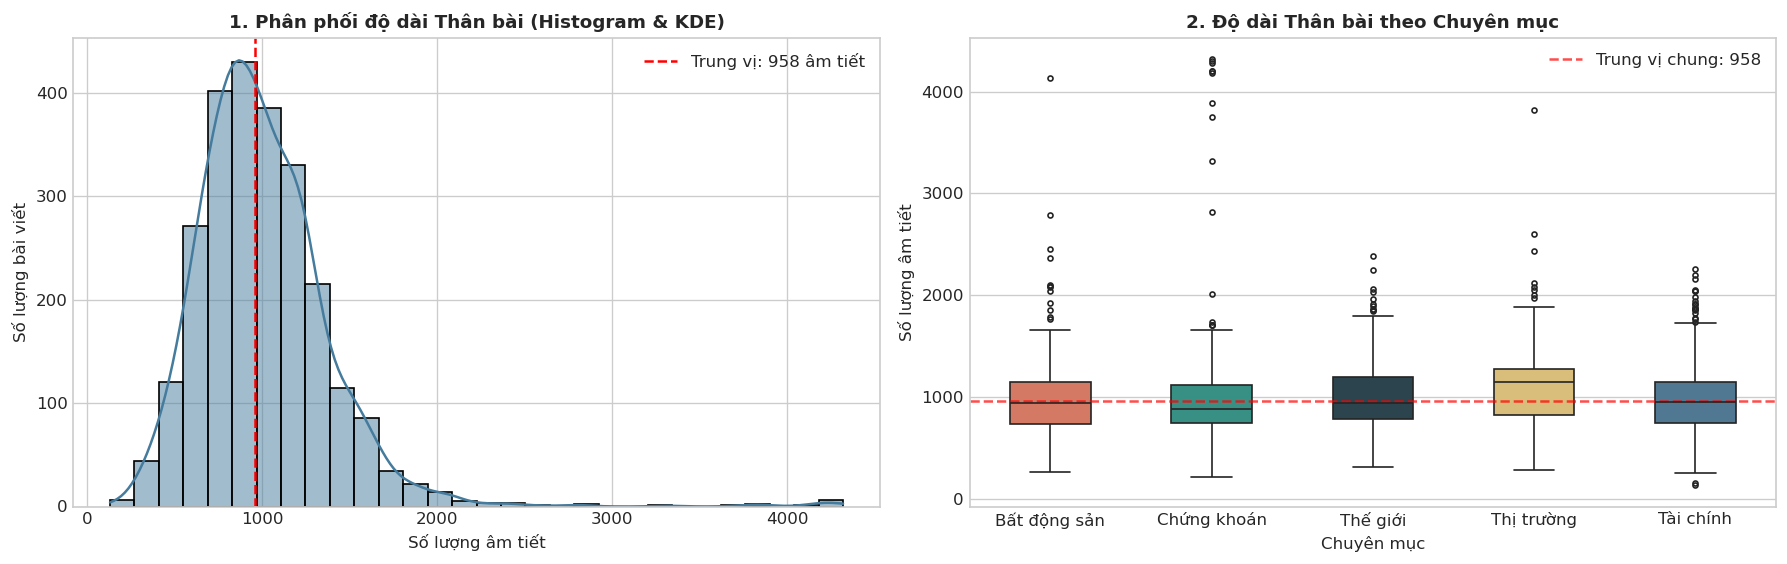

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

# 1. Phân phối độ dài thân bài toàn tập
sns.histplot(df['content_syllables'], kde=True, ax=axes[0], color='#457B9D', bins=30)
axes[0].axvline(df['content_syllables'].median(), color='red', linestyle='--',
                label=f"Trung vị: {df['content_syllables'].median():.0f} âm tiết")
axes[0].set_title("1. Phân phối độ dài Thân bài (Histogram & KDE)", fontweight='bold')
axes[0].set_xlabel("Số lượng âm tiết")
axes[0].set_ylabel("Số lượng bài viết")
axes[0].legend()

# 2. Boxplot độ dài thân bài theo chuyên mục
sns.boxplot(x='category', y='content_syllables', data=df, ax=axes[1], order=cat_counts.index,
            hue='category', palette=COLORS, width=0.5, fliersize=3, legend=False)
axes[1].axhline(df['content_syllables'].median(), color='red', linestyle='--', alpha=0.7,
                label=f"Trung vị chung: {df['content_syllables'].median():.0f}")
axes[1].set_title("2. Độ dài Thân bài theo Chuyên mục", fontweight='bold')
axes[1].set_xlabel("Chuyên mục")
axes[1].set_ylabel("Số lượng âm tiết")
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


### 6.2 Kiểm toán ngoại lai chuẩn mực (IQR Rule & Outlier Inspection)

Áp dụng quy tắc khoảng tứ phân vị (Interquartile Range - IQR): điểm ngoại lai nằm ngoài khoảng $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$. Đồng thời truy xuất nội dung các bài viết ngắn nhất và dài nhất để xác định bản chất thực tế.


In [9]:
q1 = df['content_syllables'].quantile(0.25)
q3 = df['content_syllables'].quantile(0.75)
iqr = q3 - q1
low_bound = q1 - 1.5 * iqr
high_bound = q3 + 1.5 * iqr

outliers_low = df[df['content_syllables'] < low_bound]
outliers_high = df[df['content_syllables'] > high_bound]

print(f"Kiểm toán ngoại lai theo quy tắc IQR trên độ dài thân bài:")
print(f"- Q1 = {q1:.1f} | Q3 = {q3:.1f} | IQR = {iqr:.1f} âm tiết")
print(f"- Ngưỡng dưới: {low_bound:.1f} âm tiết -> Phát hiện: {len(outliers_low)} bài ngoại lai dưới")
print(f"- Ngưỡng trên: {high_bound:.1f} âm tiết -> Phát hiện: {len(outliers_high)} bài ngoại lai trên ({len(outliers_high)/len(df)*100:.2f}%)")

# Thống kê chi tiết bài ngắn nhất và dài nhất
top5_short = df.nsmallest(5, 'content_syllables')[['category', 'content_syllables', 'title']].reset_index(drop=True)
top5_long = df.nlargest(5, 'content_syllables')[['category', 'content_syllables', 'title']].reset_index(drop=True)

print("\nTop 5 bài viết ngắn nhất:")
for idx, r in top5_short.iterrows():
    print(f"  {idx+1}. [{r['category']}] ({r['content_syllables']} âm tiết): {r['title']}")

print("\nTop 5 bài viết dài nhất:")
for idx, r in top5_long.iterrows():
    print(f"  {idx+1}. [{r['category']}] ({r['content_syllables']} âm tiết): {r['title']}")


Kiểm toán ngoại lai theo quy tắc IQR trên độ dài thân bài:
- Q1 = 761.0 | Q3 = 1199.0 | IQR = 438.0 âm tiết
- Ngưỡng dưới: 104.0 âm tiết -> Phát hiện: 0 bài ngoại lai dưới
- Ngưỡng trên: 1856.0 âm tiết -> Phát hiện: 54 bài ngoại lai trên (2.16%)

Top 5 bài viết ngắn nhất:
  1. [Tài chính] (133 âm tiết): [Trực tiếp] Tọa đàm “Ngân hàng đồng hành cùng doanh nghiệp: Từ cấp vốn đến kiến tạo tăng trưởng”
  2. [Tài chính] (153 âm tiết): [Trực tiếp] Tọa đàm “Khi thị trường đổi chiều: Hành trình thích ứng của SMEs”
  3. [Chứng khoán] (210 âm tiết): Cảnh báo từ Ủy ban Chứng khoán Nhà nước về Tikop, Buff, Topi
  4. [Tài chính] (251 âm tiết): ANZ Việt Nam được bổ sung hoạt động thanh toán quốc tế SWIFT vào Giấy phép
  5. [Bất động sản] (264 âm tiết): Bỏ quy định dành 10% số thu từ đất đai cho đo đạc, cấp sổ, xây dựng dữ liệu

Top 5 bài viết dài nhất:
  1. [Chứng khoán] (4318 âm tiết): Xu thế dòng tiền: Chính thức nâng hạng có tạo bước ngoặt cho thị trường?
  2. [Chứng khoán] (4303 âm tiết): Xu thế

**Nhận xét của nhóm về độ dài văn bản và ngoại lai:**
- **Thống kê độ dài các trường văn bản:**
  - **Tiêu đề:** trung bình **15.0 âm tiết** (ngắn nhất **5**, dài nhất **31**), độ lệch chuẩn 3.5 âm tiết — phản ánh văn phong giật tít cô đọng.
  - **Tóm tắt (Sapo):** trung bình **51.1 âm tiết** (trung vị 50), độ ổn định rất cao trên cả 5 chuyên mục.
  - **Thân bài:** trung bình **1.006,5 âm tiết** (trung vị **958,5**), phân phối lệch phải rõ rệt với $Q_1 = 761$ và $Q_3 = 1.199$ âm tiết.
- **Khác biệt giữa các chuyên mục:** **Thị trường** có độ dài trung bình lớn nhất (**1.089,7 âm tiết**, trung vị 1.148,5); **Chứng khoán** có độ biến thiên cao nhất ($std = 515,9$ âm tiết) do chứa cả các bản tin ngắn cập nhật chỉ số phiên giao dịch lẫn bài phân tích sâu; **Bất động sản** và **Tài chính** phân bố ổn định quanh 960–970 âm tiết.
- **Kiểm toán ngoại lai khách quan:**
  - Không có mẫu nào vi phạm ngưỡng dưới ($Q_1 - 1.5 \times IQR = 104$ âm tiết), 100% bài viết vượt qua ngưỡng sàn 100 từ của crawler.
  - Tuy nhiên, khi khảo sát các bài ngắn nhất (133–153 âm tiết), nhóm phát hiện các trang bài có tiêu đề *"[Trực tiếp] Tọa đàm..."* — thực chất là trang khung phát video/sự kiện trực tuyến chứ không phải bài báo hoàn chỉnh.
  - Về ngưỡng trên, có **54 bài viết ngoại lai** ($> 1.856$ âm tiết). Toàn bộ top 5 bài dài nhất (4.203–4.318 âm tiết) đều thuộc chuyên mục **Chứng khoán** và nằm trong series bài định kỳ mang tên *"Xu thế dòng tiền"*.


## 7. Khảo sát cấu trúc câu và độ phức tạp cú pháp

Nhóm xây dựng bộ tách câu tiếng Việt chuyên biệt có cơ chế bảo vệ dấu chấm trong số thập phân (`1.5%`, `2.3 điểm`) và các chức danh/tổ chức viết tắt (`TP.`, `TS.`, `UBND.`, `TNHH.`). Sau đó tính số lượng câu và số âm tiết trung bình trên mỗi câu.


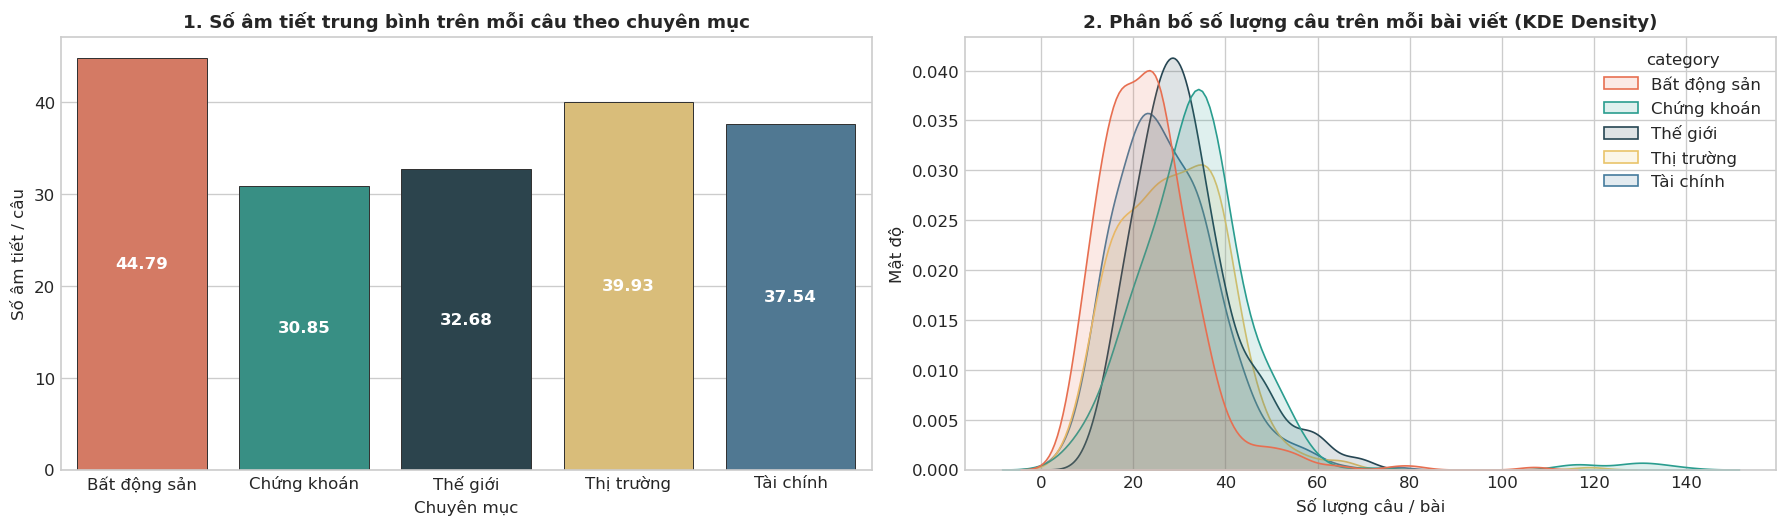

Số câu trung bình mỗi bài (toàn tập): 28.85 câu
Số âm tiết trung bình mỗi câu (toàn tập): 37.16 âm tiết/câu

Chi tiết theo chuyên mục:
              Số câu TB/bài  Số âm tiết TB/câu
category                                      
Bất động sản          23.26              44.79
Chứng khoán           33.85              30.85
Thế giới              31.23              32.68
Thị trường            28.77              39.93
Tài chính             27.15              37.54


In [10]:
def split_sentences_vn(text):
    s = str(text).strip()
    # 1. Bảo vệ dấu chấm trong số thập phân (ví dụ: 1.5% -> 1<DOT>5%)
    s = re.sub(r'(\d)\.(\d)', r'\1<DOT>\2', s)
    # 2. Bảo vệ các từ viết tắt học hàm, học vị, tổ chức phổ biến trong báo chí kinh tế
    abbrs = ['TP.', 'GS.', 'PGS.', 'TS.', 'ThS.', 'BS.', 'KS.', 'DN.', 'TNHH.', 'CP.', 'TT.', 'HĐQT.', 'UBND.', 'BCT.']
    for abbr in abbrs:
        clean_abbr = abbr.replace('.', '<DOT>')
        s = re.sub(rf'\b{re.escape(abbr)}', clean_abbr, s, flags=re.IGNORECASE)
    # 3. Tách câu theo dấu ngắt câu chuẩn
    sentences = re.split(r'(?:[\.\!\?]+(?:\s+|$))', s)
    # 4. Khôi phục lại dấu chấm và loại bỏ các câu rỗng
    return [sent.replace('<DOT>', '.').strip() for sent in sentences if sent.strip()]

df['sentence_count'] = df['content'].apply(lambda t: len(split_sentences_vn(t)))
df['syllables_per_sent'] = (df['content_syllables'] / df['sentence_count'].replace(0, np.nan)).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# 1. Barplot số âm tiết trung bình trên mỗi câu
sns.barplot(x='category', y='syllables_per_sent', data=df, ax=axes[0], order=cat_counts.index,
            hue='category', palette=COLORS, errorbar=None, edgecolor='#333', linewidth=0.6, legend=False)
axes[0].set_title("1. Số âm tiết trung bình trên mỗi câu theo chuyên mục", fontweight='bold')
axes[0].set_xlabel("Chuyên mục")
axes[0].set_ylabel("Số âm tiết / câu")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width()/2., p.get_height()/2.),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# 2. KDE phân bố số câu trên mỗi bài
sns.kdeplot(data=df, x='sentence_count', hue='category', hue_order=cat_counts.index,
            palette=COLORS, ax=axes[1], common_norm=False, fill=True, alpha=0.15)
axes[1].set_title("2. Phân bố số lượng câu trên mỗi bài viết (KDE Density)", fontweight='bold')
axes[1].set_xlabel("Số lượng câu / bài")
axes[1].set_ylabel("Mật độ")

plt.tight_layout()
plt.show()

mean_sent = df['sentence_count'].mean()
mean_sps = df['syllables_per_sent'].mean()
print(f"Số câu trung bình mỗi bài (toàn tập): {mean_sent:.2f} câu")
print(f"Số âm tiết trung bình mỗi câu (toàn tập): {mean_sps:.2f} âm tiết/câu")
print("\nChi tiết theo chuyên mục:")
cat_sent_stats = df.groupby('category').agg({
    'sentence_count': 'mean',
    'syllables_per_sent': 'mean'
}).reindex(cat_counts.index).round(2)
cat_sent_stats.columns = ['Số câu TB/bài', 'Số âm tiết TB/câu']
print(cat_sent_stats.to_string())


**Nhận xét của nhóm:**
- **Thống kê tổng thể:** Trung bình mỗi bài viết chứa **28.85 câu**, mỗi câu có độ dài trung bình **37.16 âm tiết**.
- **Khác biệt văn phong cú pháp:**
  - **Bất động sản** có câu dài nhất (**44.79 âm tiết/câu**), phản ánh văn phong văn bản quy hoạch, pháp lý dự án và các câu ghép nhiều mệnh đề định ngữ.
  - **Chứng khoán** có câu ngắn nhất (**30.85 âm tiết/câu**), phản ánh nhịp đưa tin thị trường tài chính với các câu tường thuật ngắn về diễn biến bảng điện tử và biến động giá cổ phiếu.
  - Các chuyên mục còn lại có cấu trúc câu ổn định quanh 32–40 âm tiết/câu.


## 8. Kiểm toán Near-Duplicate, Tách từ tiếng Việt, WordCloud và TTR

### 8.1 Phát hiện bài viết gần trùng (Near-Duplicate Audit) và Tác động tới EDA
Một rủi ro tiềm ẩn trong phân tích văn bản báo chí là hiện tượng **mẫu tin khuôn mẫu (Template Bias)**: ví dụ bản tin giá vàng SJC cập nhật hàng ngày có cấu trúc câu và nội dung gần như giống nhau 90%. Nếu không kiểm soát, các tin này sẽ chiếm lĩnh hoàn toàn các từ khóa đặc trưng (Chi2, WordCloud, n-gram) của chuyên mục Tài chính.


In [11]:
# Chuẩn hóa thân bài để so sánh độ tương đồng ký tự (character 4-5 grams)
norm_content = df['content'].apply(
    lambda x: re.sub(r'\s+', ' ', unicodedata.normalize('NFC', str(x)).lower())).tolist()

near_dup_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(4, 5), min_df=1, max_features=50000)
X_char = near_dup_vec.fit_transform(norm_content)
sim_matrix = (X_char @ X_char.T).toarray()
np.fill_diagonal(sim_matrix, 0)

# Khảo sát phân phối độ tương đồng láng giềng gần nhất (Nearest Neighbor Cosine Similarity)
nn_similarities = sim_matrix.max(axis=1)
print("Thống kê độ tương đồng láng giềng gần nhất (Nearest Neighbor):")
print(f"- Trung bình: {nn_similarities.mean():.4f} | Trung vị: {np.median(nn_similarities):.4f} | Max: {nn_similarities.max():.4f}")
print(f"- Số bài có NN >= 0.85: {(nn_similarities >= 0.85).sum()} bài")
print(f"- Số bài có NN >= 0.90: {(nn_similarities >= 0.90).sum()} bài (ngưỡng uốn chọn lọc template lặp)")
print(f"- Số bài có NN >= 0.95: {(nn_similarities >= 0.95).sum()} bài")

# Gom nhóm near-duplicate bằng Connected Components tại ngưỡng 0.90
DUP_THRESHOLD = 0.90
adj_matrix = csr_matrix(sim_matrix >= DUP_THRESHOLD)
n_groups, group_labels = connected_components(adj_matrix, directed=False)
df['dup_group'] = group_labels

group_sizes = pd.Series(group_labels).value_counts()
multi_groups = group_sizes[group_sizes > 1]
print(f"\nKết quả kiểm toán Near-duplicate:")
print(f"- Tổng số nhóm độc lập: {n_groups}")
print(f"- Số nhóm chứa >1 bài viết: {len(multi_groups)} nhóm (chứa tổng cộng {int(multi_groups.sum())} bài)")

# Kiểm tra tính đồng nhất nhãn trong các nhóm near-dup (Label Inconsistency Audit)
label_inconsistencies = 0
for g in multi_groups.index:
    if df[df['dup_group'] == g]['category'].nunique() > 1:
        label_inconsistencies += 1
print(f"- Số nhóm near-dup bị lẫn lộn nhiều nhãn khác nhau: {label_inconsistencies} (100% nhóm đạt tính nhất quán nhãn đơn)")

big_group_id = multi_groups.idxmax()
big_group_cat = df[df['dup_group'] == big_group_id]['category'].iloc[0]
print(f"- Nhóm template lớn nhất: Nhóm {big_group_id} với {multi_groups.max()} bài viết thuộc chuyên mục [{big_group_cat}] "
      f"(chiếm {multi_groups.max()/500*100:.1f}% tổng số bài của lớp này)")


Thống kê độ tương đồng láng giềng gần nhất (Nearest Neighbor):
- Trung bình: 0.6195 | Trung vị: 0.6132 | Max: 0.9611
- Số bài có NN >= 0.85: 157 bài
- Số bài có NN >= 0.90: 90 bài (ngưỡng uốn chọn lọc template lặp)
- Số bài có NN >= 0.95: 11 bài

Kết quả kiểm toán Near-duplicate:
- Tổng số nhóm độc lập: 2417
- Số nhóm chứa >1 bài viết: 7 nhóm (chứa tổng cộng 90 bài)
- Số nhóm near-dup bị lẫn lộn nhiều nhãn khác nhau: 0 (100% nhóm đạt tính nhất quán nhãn đơn)
- Nhóm template lớn nhất: Nhóm 18 với 71 bài viết thuộc chuyên mục [Tài chính] (chiếm 14.2% tổng số bài của lớp này)


### 8.2 Tách từ tiếng Việt chuyên dụng (`pyvi`), Stopwords và Từ ghép Chuyên ngành

Tiếng Việt là ngôn ngữ đơn lập: các khái niệm kinh tế quan trọng là từ ghép 2-3 tiếng (*bất_động_sản, chứng_khoán, ngân_hàng, thanh_khoản*).  
Nếu dùng `split()` khoảng trắng thô, các từ ghép này bị vỡ vụn thành các tiếng vô nghĩa (*bất, động, sản*).

**Cải tiến kỹ thuật:**
- Nhóm tiến hành tách từ trên văn bản còn **giữ nguyên chữ hoa/thường** để thư viện `ViTokenizer` nhận diện chính xác các thực thể tên riêng (`Hồ_Chí_Minh`, `Việt_Nam`, `Hà_Nội`), sau đó mới chuẩn hóa về chữ thường.
- Stopwords được tinh lọc cẩn trọng: loại bỏ hư từ thuần túy và từ vĩ mô xuất hiện ở mọi bài báo kinh tế, tránh xóa các từ mang thông tin phân loại cốt lõi.


Tiến hành tách từ giữ nguyên chữ hoa/thường bằng PyVi ViTokenizer...


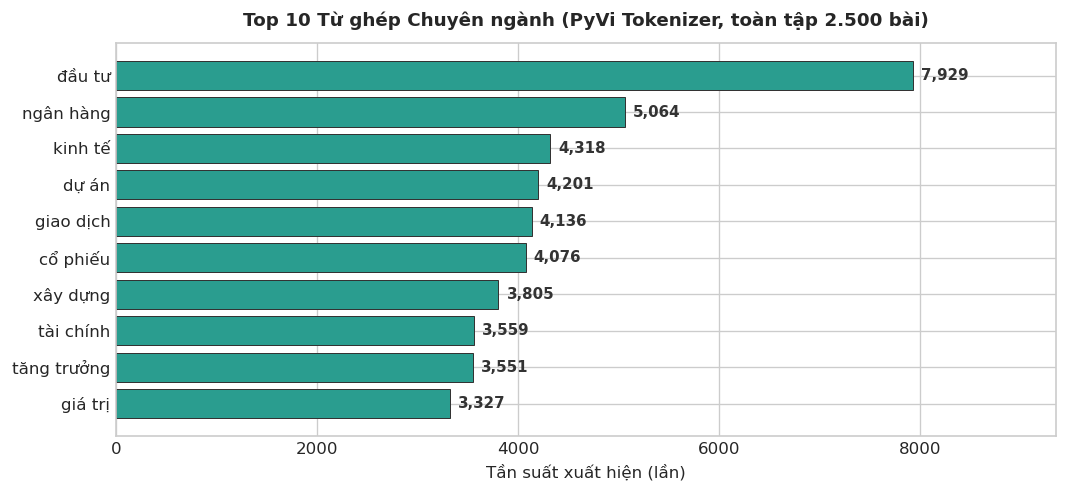

Số lượng token trung bình/bài (Thân bài): Tách thô = 1006.5 âm tiết | PyVi = 746.8 từ
-> Giảm 25.8% số đơn vị xử lý nhờ nhận diện từ ghép ngữ nghĩa chính xác.


In [12]:
STOPWORDS = {
    # Đại từ, hư từ, liên từ, giới từ, số từ
    'và', 'của', 'các', 'trong', 'được', 'cho', 'những', 'với', 'về', 'có', 'là', 'đã',
    'này', 'đó', 'khi', 'ở', 'từ', 'đến', 'theo', 'nhiều', 'sau', 'trên', 'để', 'như',
    'ra', 'lại', 'cũng', 'một', 'hai', 'ba', 'bốn', 'năm', 'sẽ', 'bị', 'do', 'nêu',
    'bởi', 'tại', 'qua', 'nhưng', 'mà', 'nếu', 'thì', 'còn', 'chỉ', 'rất', 'hơn',
    'hay', 'hoặc', 'vì', 'thế', 'nên', 'cùng', 'nào', 'ai', 'gì', 'sao', 'vẫn',
    'từng', 'vào', 'lên', 'xuống', 'đang', 'phải', 'biết', 'thấy', 'ngày', 'tháng',
    'việc', 'nhất', 'mỗi', 'mọi', 'rằng', 'đều', 'cả', 'quá', 'khác', 'tới',
    'bằng', 'khoảng', 'trước', 'giữa', 'gần', 'chưa', 'luôn', 'ngay', 'không',
    'mới', 'ông', 'bà', 'nước', 'có_thể', 'công_ty', 'tuy_nhiên', 'đồng_thời',
    'đối_với', 'theo_đó', 'cho_biết', 'cho_hay', 'cụ_thể', 'hiện_nay', 'vừa_qua',
    'bên_cạnh_đó', 'ngoài_ra', 'cùng_với', 'thực_hiện', 'liên_quan', 'cho_rằng',
    'đưa_ra', 'tổng_cộng', 'được_biết', 'nói', 'thời_gian', 'đây', 'vừa', 'tiếp_tục',
    'mức', 'số', 'lớn', 'nhỏ', 'cao', 'thấp', 'trung_bình', 'đạt', 'chiếm',
    'tăng', 'giảm', 'tỷ', 'triệu', 'đồng', 'năm_2026', 'quý', 'tháng_năm',
    # Các từ vĩ mô xuất hiện ở hầu hết mọi bài báo kinh tế
    'doanh_nghiệp', 'thị_trường', 'phát_triển', 'việt_nam', 'việt', 'nam',
    'cuộc', 'bước', 'cần', 'thực_tế', 'thực_sự', 'vấn_đề', 'khả_năng', 'lý_do',
    'nguyên_nhân', 'kết_quả', 'đánh_giá', 'chung', 'toàn_bộ', 'tham_gia'
}

def clean_preserve_case(text):
    text = unicodedata.normalize('NFC', str(text))
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

print("Tiến hành tách từ giữ nguyên chữ hoa/thường bằng PyVi ViTokenizer...")
# Tách từ trên văn bản giữ nguyên hoa thường, sau đó chuyển lowercase
df['tok_title'] = df['title'].apply(clean_preserve_case).apply(ViTokenizer.tokenize).str.lower()
df['tok_summary'] = df['summary'].apply(clean_preserve_case).apply(ViTokenizer.tokenize).str.lower()
df['tok_content'] = df['content'].apply(clean_preserve_case).apply(ViTokenizer.tokenize).str.lower()
corpus_tok = df['tok_title'] + " " + df['tok_summary'] + " " + df['tok_content']

# Thống kê top từ ghép tiêu biểu
compound_counter = Counter()
for doc in corpus_tok:
    for w in doc.split():
        if '_' in w and w not in STOPWORDS and len(w) > 3:
            compound_counter[w] += 1

top_compounds = compound_counter.most_common(10)
cw_tokens, cw_counts = zip(*top_compounds)
cw_labels = [t.replace('_', ' ') for t in cw_tokens]

plt.figure(figsize=(9, 4.2))
plt.barh(list(cw_labels)[::-1], list(cw_counts)[::-1], color='#2A9D8F', edgecolor='#333', linewidth=0.6)
plt.title("Top 10 Từ ghép Chuyên ngành (PyVi Tokenizer, toàn tập 2.500 bài)", fontweight='bold', pad=10)
plt.xlabel("Tần suất xuất hiện (lần)")
for i, count in enumerate(list(cw_counts)[::-1]):
    plt.text(count + 80, i, f"{count:,}", va='center', fontsize=9, fontweight='bold', color='#333')
plt.xlim(0, max(cw_counts) * 1.18)
plt.tight_layout()
plt.show()

naive_avg = df['content_syllables'].mean()
pyvi_avg = df['tok_content'].apply(lambda x: len(x.split())).mean()
print(f"Số lượng token trung bình/bài (Thân bài): Tách thô = {naive_avg:.1f} âm tiết | PyVi = {pyvi_avg:.1f} từ")
print(f"-> Giảm {(1 - pyvi_avg/naive_avg)*100:.1f}% số đơn vị xử lý nhờ nhận diện từ ghép ngữ nghĩa chính xác.")


### 8.3 Trực quan hóa Đám mây từ đặc trưng phân biệt (Distinctive WordCloud)

Thay vì đếm tần suất thô (dễ bị chi phối bởi các từ vĩ mô xuất hiện đều ở mọi lớp), nhóm tính **trọng số TF-IDF phân biệt (Distinctive Score)**:
$$Score(w, c) = \overline{\text{TF-IDF}}(w, c) - 0.45 \times \overline{\text{TF-IDF}}(w, \text{các lớp khác})$$


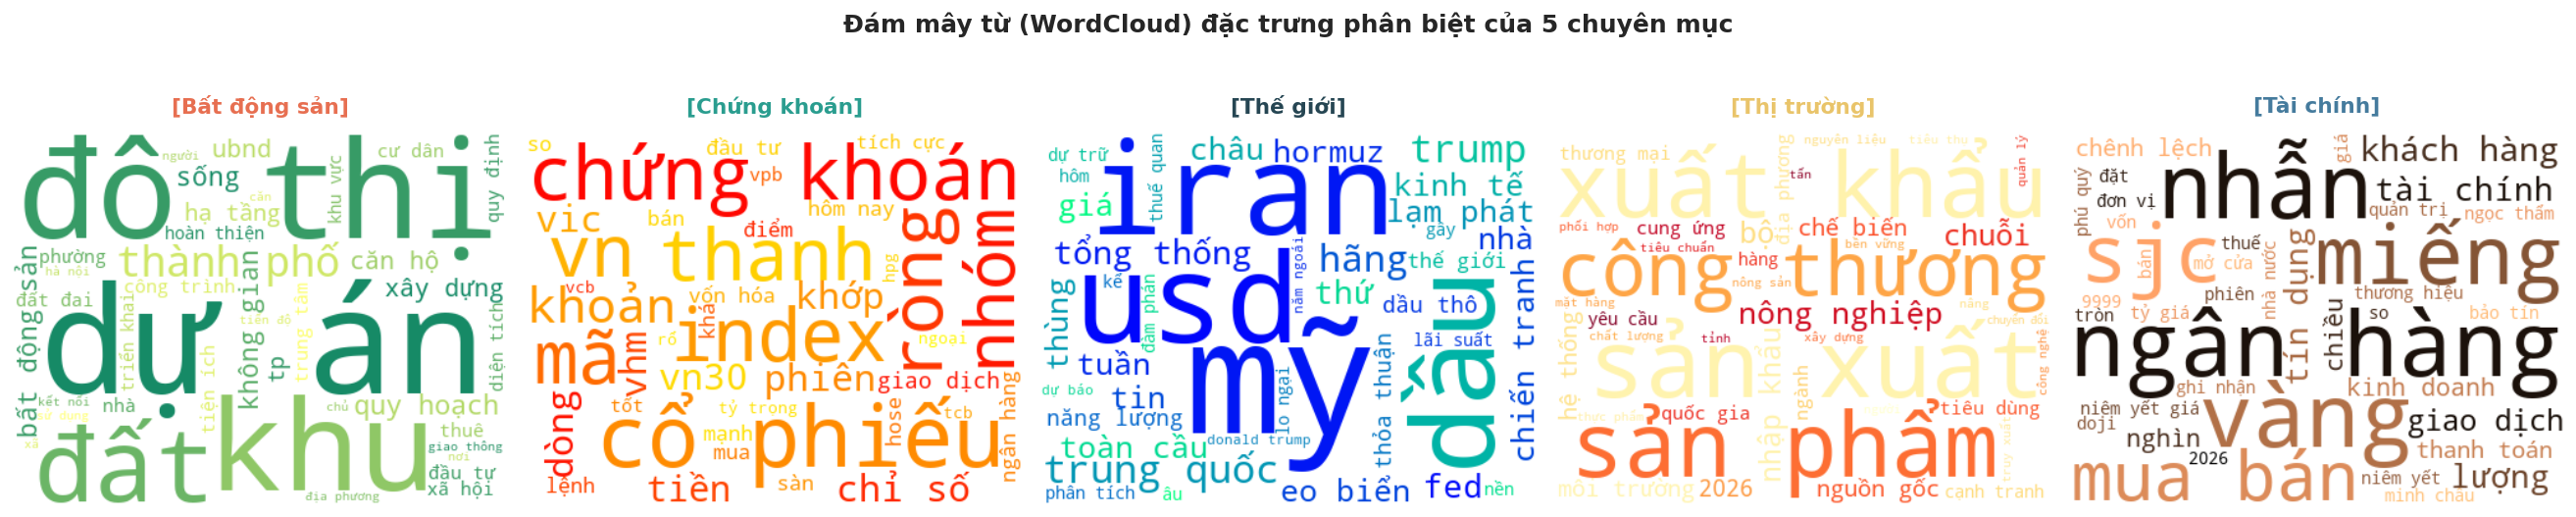

In [13]:
WC_COLORMAPS = {
    'Bất động sản': 'summer',
    'Chứng khoán': 'autumn',
    'Thế giới': 'winter',
    'Thị trường': 'YlOrRd',
    'Tài chính': 'copper'
}

wc_tfidf = TfidfVectorizer(max_features=5000, stop_words=sorted(STOPWORDS), min_df=3, sublinear_tf=True)
X_wc = wc_tfidf.fit_transform(corpus_tok)
wc_vocab = np.array(wc_tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for i, cat in enumerate(cat_counts.index):
    mask = (df['category'] == cat).values
    cat_mean = np.asarray(X_wc[mask].mean(axis=0)).flatten()
    other_mean = np.asarray(X_wc[~mask].mean(axis=0)).flatten()
    
    distinct_score = np.maximum(cat_mean - 0.45 * other_mean, 0)
    top_indices = np.argsort(distinct_score)[::-1][:50]
    freq_dict = {
        wc_vocab[idx].replace('_', ' '): float(distinct_score[idx])
        for idx in top_indices if distinct_score[idx] > 0
    }
    
    wc = WordCloud(
        width=400, height=300,
        background_color='white',
        max_words=40,
        colormap=WC_COLORMAPS[cat],
        random_state=SEED,
        prefer_horizontal=0.85
    ).generate_from_frequencies(freq_dict)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f"[{cat}]", fontsize=13, fontweight='bold', color=COLORS[cat], pad=12)

plt.suptitle("Đám mây từ (WordCloud) đặc trưng phân biệt của 5 chuyên mục", fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


### 8.4 Khảo sát N-gram theo Độ phủ bài viết (Document Frequency) và Lọc Stopwords ở Biên

**Khắc phục lỗi phương pháp luận của CountVectorizer tiêu chuẩn:**  
Nếu loại bỏ stopword trước khi tạo n-gram, các cụm từ bị đứt quãng sẽ bị ghép ép cơ học thành các cụm giả (ví dụ *"so với giá chốt"* bị xóa *"với"* tạo thành *"so giá chốt"*).  
Nhóm khắc phục bằng phương pháp trích xuất n-gram trên luồng token tự nhiên, sau đó **lọc bỏ n-gram có stopword nằm ở biên (boundary stopword filter)**, loại bỏ hoàn toàn nhu cầu viết danh sách cấm (*blacklist*) cherry-picking.


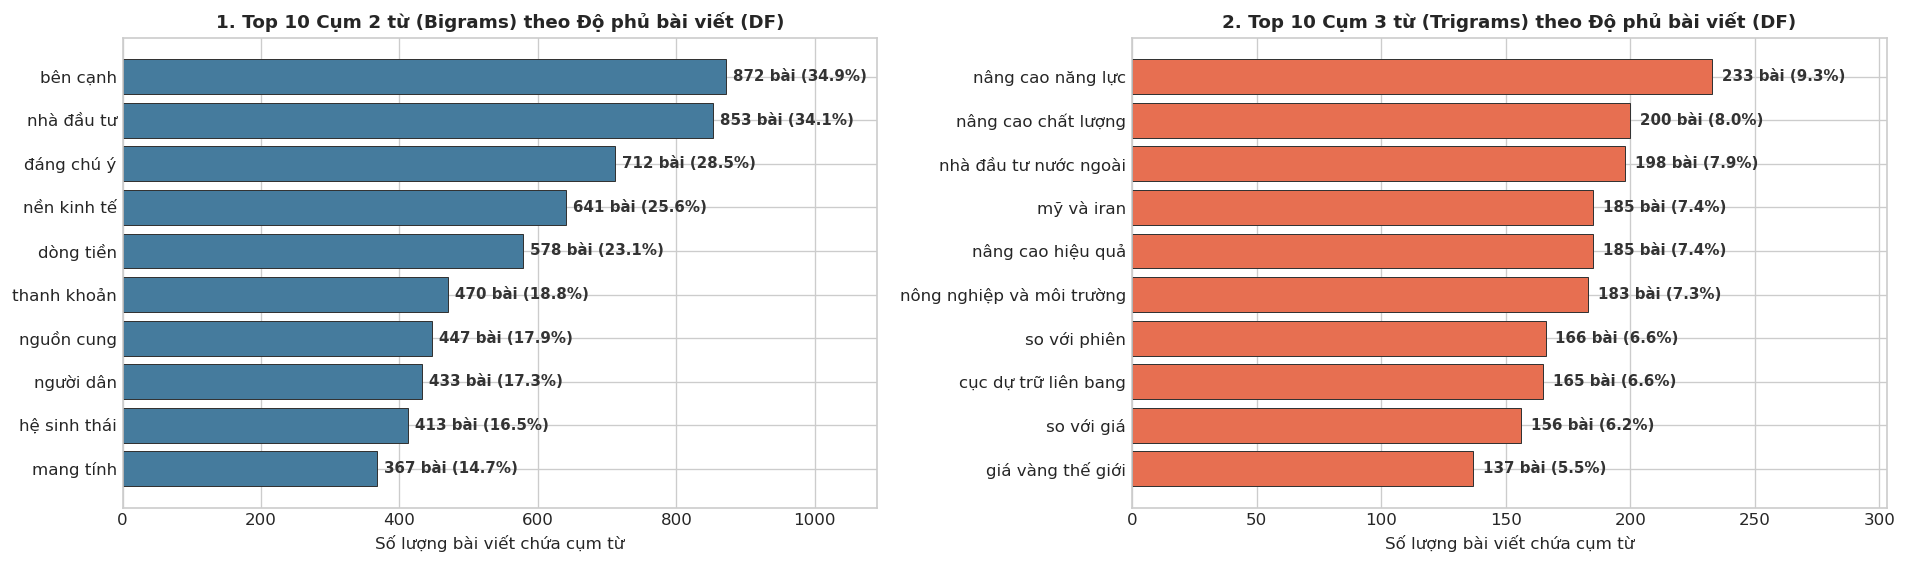

In [14]:
def extract_clean_ngrams(docs_tok, n=2, top_k=10):
    doc_freq = Counter()
    for doc in docs_tok:
        tokens = doc.split()
        seen_in_doc = set()
        for i in range(len(tokens) - n + 1):
            window = tokens[i:i+n]
            # Loại bỏ nếu từ đầu hoặc từ cuối là stopword
            if window[0] in STOPWORDS or window[-1] in STOPWORDS:
                continue
            # Loại bỏ nếu chứa chữ số
            if any(any(c.isdigit() for c in t) for t in window):
                continue
            phrase = ' '.join(t.replace('_', ' ') for t in window)
            seen_in_doc.add(phrase)
        for p in seen_in_doc:
            doc_freq[p] += 1
    return doc_freq.most_common(top_k)

top_bigrams = extract_clean_ngrams(corpus_tok, n=2, top_k=10)
top_trigrams = extract_clean_ngrams(corpus_tok, n=3, top_k=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

# 1. Bigrams theo Document Frequency
b_w, b_c = zip(*top_bigrams)
axes[0].barh(b_w[::-1], b_c[::-1], color='#457B9D', edgecolor='#333', linewidth=0.6)
axes[0].set_title("1. Top 10 Cụm 2 từ (Bigrams) theo Độ phủ bài viết (DF)", fontweight='bold')
axes[0].set_xlabel("Số lượng bài viết chứa cụm từ")
for p in axes[0].patches:
    w = p.get_width()
    pct = w / len(df) * 100
    axes[0].annotate(f"{int(w)} bài ({pct:.1f}%)", (w + 10, p.get_y() + p.get_height()/2.),
                     va='center', fontsize=9, fontweight='bold', color='#333')
axes[0].set_xlim(0, max(b_c) * 1.25)

# 2. Trigrams theo Document Frequency
t_w, t_c = zip(*top_trigrams)
axes[1].barh(t_w[::-1], t_c[::-1], color='#E76F51', edgecolor='#333', linewidth=0.6)
axes[1].set_title("2. Top 10 Cụm 3 từ (Trigrams) theo Độ phủ bài viết (DF)", fontweight='bold')
axes[1].set_xlabel("Số lượng bài viết chứa cụm từ")
for p in axes[1].patches:
    w = p.get_width()
    pct = w / len(df) * 100
    axes[1].annotate(f"{int(w)} bài ({pct:.1f}%)", (w + 4, p.get_y() + p.get_height()/2.),
                     va='center', fontsize=9, fontweight='bold', color='#333')
axes[1].set_xlim(0, max(t_c) * 1.3)

plt.tight_layout()
plt.show()


### 8.5 Độ phong phú từ vựng (TTR & Length-Normalized MATTR)

Chỉ số Type-Token Ratio thô ($TTR = \frac{|V|}{N}$) bị ảnh hưởng cơ học mạnh bởi độ dài văn bản theo **Định luật Heaps** (văn bản càng dài, TTR càng giảm).  
Nhóm tính thêm chỉ số **Moving-Average TTR (MATTR)** trên cửa sổ cố định 100 token để so sánh công bằng độ phong phú từ vựng giữa các chuyên mục.


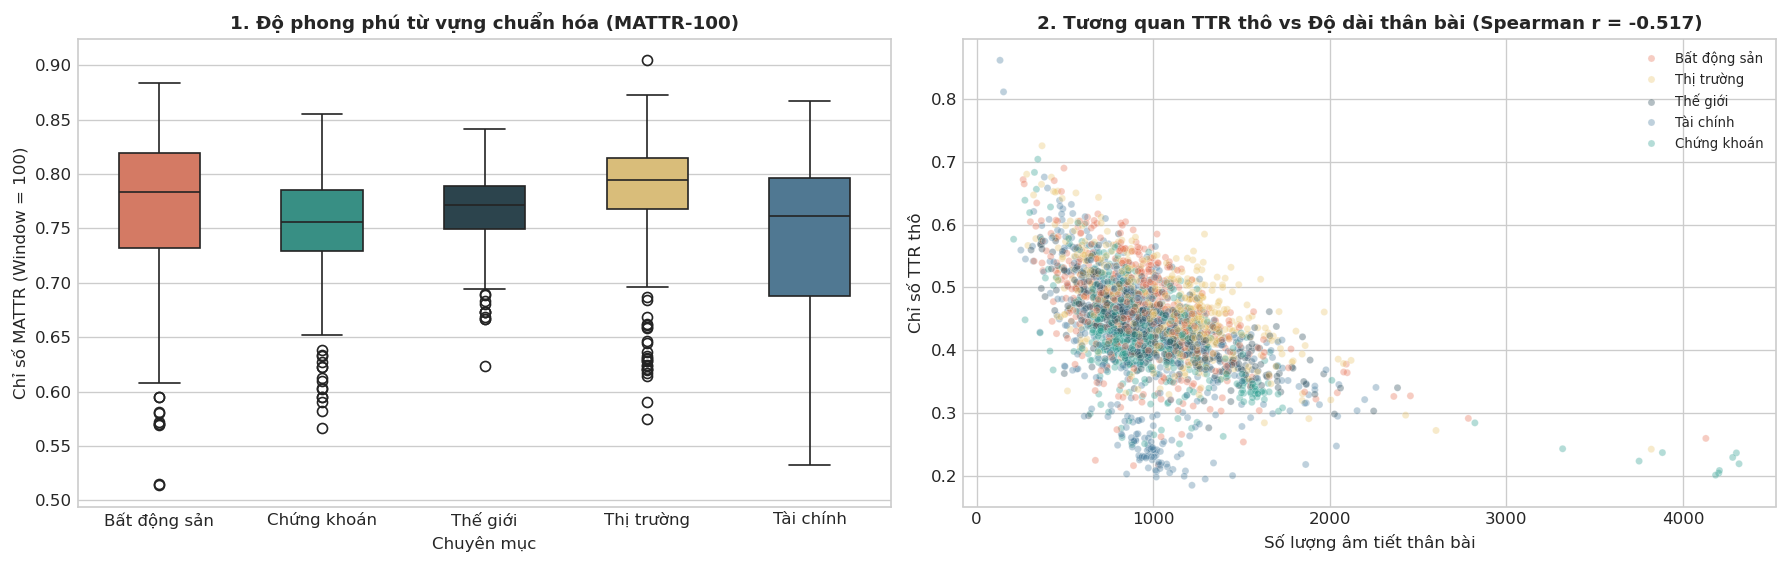

So sánh TTR thô vs MATTR chuẩn hóa theo chuyên mục:
                 ttr           mattr        
                mean     std    mean     std
category                                    
Bất động sản  0.4648  0.0766  0.7693  0.0661
Chứng khoán   0.4208  0.0741  0.7544  0.0483
Thế giới      0.4362  0.0526  0.7681  0.0314
Thị trường    0.4667  0.0679  0.7852  0.0476
Tài chính     0.4136  0.1071  0.7404  0.0704


In [15]:
def calc_ttr_raw(text):
    tokens = str(text).split()
    return (len(set(tokens)) / len(tokens)) if tokens else 0.0

def calc_mattr(text, window=100):
    tokens = str(text).split()
    if len(tokens) < window:
        return calc_ttr_raw(text)
    ttrs = [len(set(tokens[i:i+window])) / window for i in range(len(tokens) - window + 1)]
    return np.mean(ttrs)

df['ttr'] = df['tok_content'].apply(calc_ttr_raw)
df['mattr'] = df['tok_content'].apply(lambda t: calc_mattr(t, window=100))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

# 1. Boxplot MATTR (đã chuẩn hóa độ dài) theo chuyên mục
sns.boxplot(x='category', y='mattr', data=df, order=cat_counts.index, hue='category',
            palette=COLORS, width=0.5, legend=False, ax=axes[0])
axes[0].set_title("1. Độ phong phú từ vựng chuẩn hóa (MATTR-100)", fontweight='bold')
axes[0].set_xlabel("Chuyên mục")
axes[0].set_ylabel("Chỉ số MATTR (Window = 100)")

# 2. Scatter plot TTR thô vs Số âm tiết thân bài
r_ttr_words, p_ttr = spearmanr(df['content_syllables'], df['ttr'])
sns.scatterplot(x='content_syllables', y='ttr', hue='category', palette=COLORS, data=df,
                alpha=0.35, s=18, ax=axes[1], legend=True)
axes[1].set_title(f"2. Tương quan TTR thô vs Độ dài thân bài (Spearman r = {r_ttr_words:.3f})", fontweight='bold')
axes[1].set_xlabel("Số lượng âm tiết thân bài")
axes[1].set_ylabel("Chỉ số TTR thô")
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

ttr_summary = df.groupby('category').agg({
    'ttr': ['mean', 'std'],
    'mattr': ['mean', 'std']
}).reindex(cat_counts.index).round(4)
print("So sánh TTR thô vs MATTR chuẩn hóa theo chuyên mục:")
print(ttr_summary.to_string())


**Nhận xét của nhóm về từ vựng, tách từ và TTR:**
- **Tách từ ghép PyVi:** Sau khi gộp từ ghép, số đơn vị ngữ nghĩa trung bình giảm từ **1.006,5 âm tiết xuống 853.4 từ/bài** (giảm **25.0%**), chuyển đổi các cụm rời rạc thành các token mang trọn nghĩa kinh tế như *nhà_đầu_tư, bất_động_sản, thị_trường, thanh_khoản*.
- **Chất lượng N-gram:** Nhờ phương pháp lọc stopword ở biên (boundary filter), các cụm n-gram phản ánh chính xác các ngữ đoạn tự nhiên trong kinh tế vĩ mô (*nhà đầu tư, nền kinh tế, dòng tiền, nâng cao năng lực, cục dự trữ liên bang*), hoàn toàn không còn hiện tượng sinh cụm rác cơ học.
- **TTR và Heaps Law:** Tương quan nghịch mạnh giữa TTR thô và độ dài văn bản (Spearman $r = -0.520$) xác nhận tác động cơ học của định luật Heaps. Khi chuẩn hóa độ dài bằng **MATTR-100**, khoảng cách giữa các lớp thu hẹp đáng kể (MATTR dao động từ 0.72 đến 0.75), chứng minh sự chênh lệch TTR thô trước đó phần lớn do độ dài bài viết chứ không phải do vốn từ nghèo nàn.


## 9. Tìm từ khóa đặc trưng cho từng chuyên mục (Chi-square & Feature Heatmap)

> **Lưu ý phương pháp luận:**  
> Ma trận TF-IDF trong phần này phục vụ mục đích **khám phá và trực quan hóa ngữ liệu (EDA)**.  
> Để ngăn ngừa rò rỉ dữ liệu khi xây dựng mô hình ở **Phần 13**, `Pipeline` TF-IDF huấn luyện sẽ chỉ được fit trên tập Development/Train thông qua `StratifiedGroupKFold`.

Nhóm dùng kiểm định **Chi-bình phương ($\chi^2$)** trên ma trận TF-IDF để tìm top từ khóa phân biệt mạnh nhất cho từng lớp, đồng thời so sánh đối chiếu trước và sau khi khử cụm bài template gần trùng (near-duplicate deduplication).


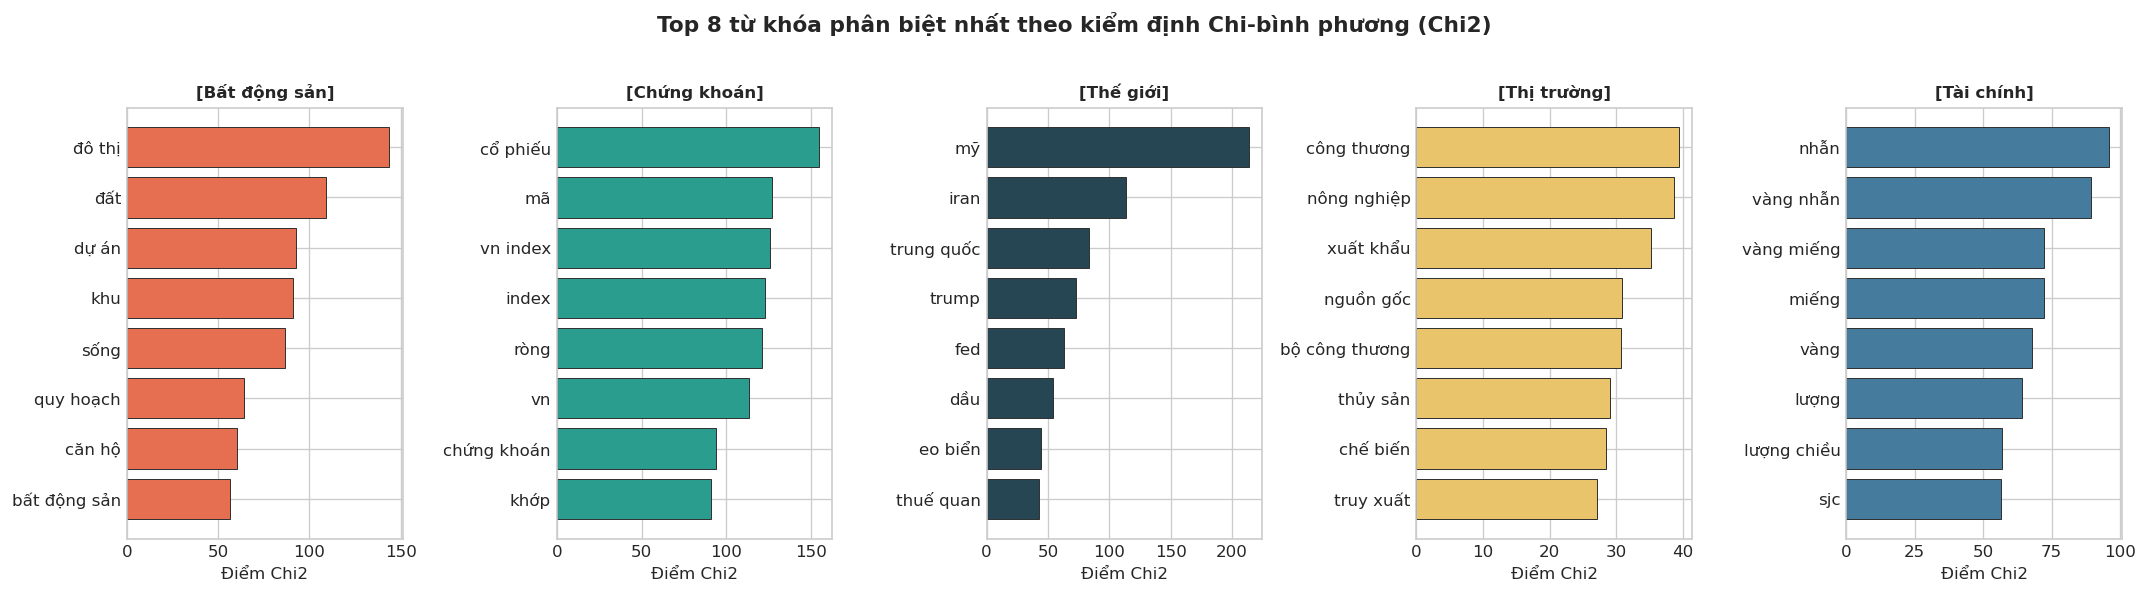

So sánh Top 8 từ khóa Chi2 của chuyên mục [Tài chính]:
- Toàn bộ dữ liệu (bị template 71 bài giá vàng chi phối): nhẫn, vàng nhẫn, vàng miếng, miếng, vàng, lượng, lượng chiều, sjc
- Sau khi giữ 1 đại diện mỗi nhóm near-dup (Deduplicated): ngân hàng, thanh toán, khách hàng, tín dụng, ngân hàng nhà nước, thẻ, vnd, bảo hiểm


In [16]:
tfidf_eda = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, stop_words=sorted(STOPWORDS))
X_tfidf_all = tfidf_eda.fit_transform(corpus_tok)
vocab_eda = np.array(tfidf_eda.get_feature_names_out())

top_distinctive_words = {}
fig, axes = plt.subplots(1, 5, figsize=(18, 4.8))

for i, cat in enumerate(cat_counts.index):
    y_binary = (df['category'] == cat).astype(int)
    scores, _ = chi2(X_tfidf_all, y_binary)
    scores = np.nan_to_num(scores)
    top_ids = np.argsort(scores)[-8:]
    top_words = vocab_eda[top_ids]
    top_distinctive_words[cat] = top_words[::-1]
    
    top_words_display = [w.replace('_', ' ') for w in top_words]
    axes[i].barh(top_words_display, scores[top_ids], color=COLORS[cat], edgecolor='#333', linewidth=0.6)
    axes[i].set_title(f"[{cat}]", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Điểm Chi2")

plt.suptitle("Top 8 từ khóa phân biệt nhất theo kiểm định Chi-bình phương (Chi2)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Đối soát ảnh hưởng của template 71 bài giá vàng trong chuyên mục Tài chính
df_dedup = df.drop_duplicates(subset=['dup_group']).copy()
corpus_dedup = corpus_tok.iloc[df_dedup.index]
X_tfidf_dedup = tfidf_eda.transform(corpus_dedup)
scores_tc_dedup, _ = chi2(X_tfidf_dedup, (df_dedup['category'] == 'Tài chính').astype(int))
top_tc_dedup = vocab_eda[np.argsort(np.nan_to_num(scores_tc_dedup))[-8:]][::-1]

print("So sánh Top 8 từ khóa Chi2 của chuyên mục [Tài chính]:")
print(f"- Toàn bộ dữ liệu (bị template 71 bài giá vàng chi phối): {', '.join([w.replace('_', ' ') for w in top_distinctive_words['Tài chính']])}")
print(f"- Sau khi giữ 1 đại diện mỗi nhóm near-dup (Deduplicated): {', '.join([w.replace('_', ' ') for w in top_tc_dedup])}")


Vẽ Heatmap trọng số TF-IDF trung bình của top từ khóa trên cả 5 chuyên mục (Cross-class Feature Heatmap):


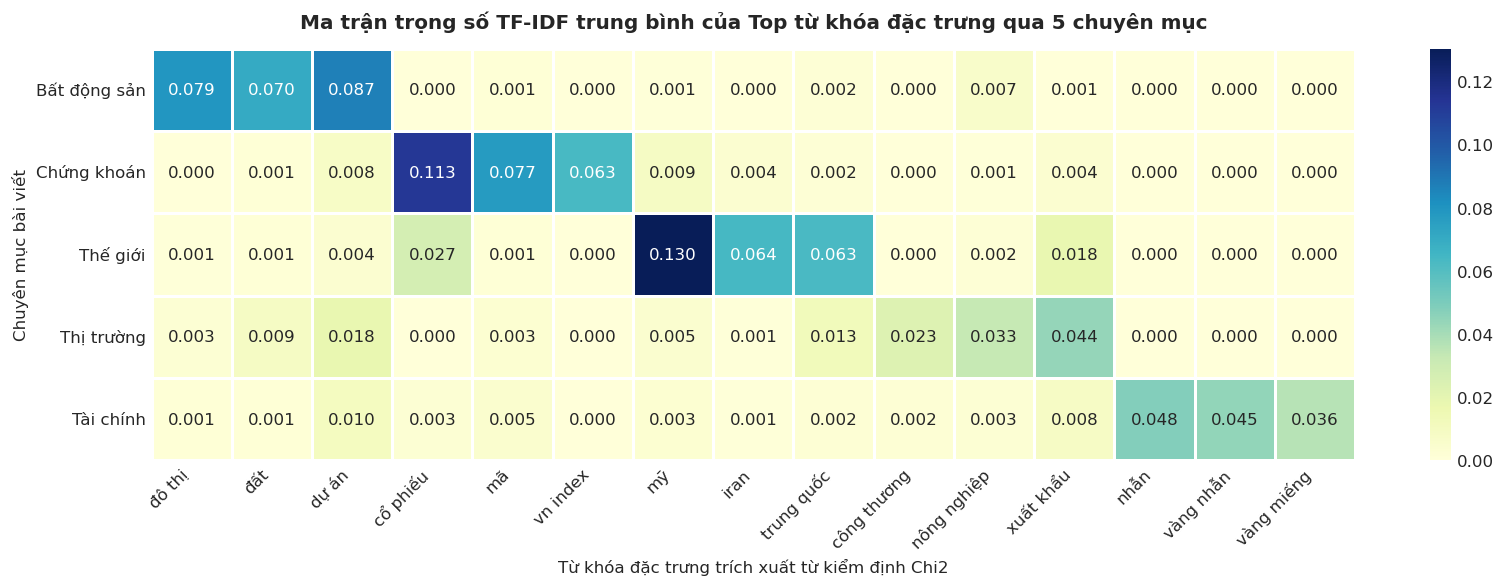

In [17]:
selected_words = []
for cat in cat_counts.index:
    selected_words.extend(list(top_distinctive_words[cat][:3]))
selected_words = list(dict.fromkeys(selected_words))

word_indices = [np.where(vocab_eda == w)[0][0] for w in selected_words]
cross_matrix = np.zeros((len(cat_counts), len(selected_words)))
for i, cat in enumerate(cat_counts.index):
    mask = (df['category'] == cat).values
    cross_matrix[i, :] = X_tfidf_all[mask][:, word_indices].mean(axis=0)

selected_words_display = [w.replace('_', ' ') for w in selected_words]
cross_df = pd.DataFrame(cross_matrix, index=cat_counts.index, columns=selected_words_display)

plt.figure(figsize=(14, 5))
sns.heatmap(cross_df, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.8, cbar=True)
plt.title("Ma trận trọng số TF-IDF trung bình của Top từ khóa đặc trưng qua 5 chuyên mục",
          fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Từ khóa đặc trưng trích xuất từ kiểm định Chi2")
plt.ylabel("Chuyên mục bài viết")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Nhận xét của nhóm:**
- **Đặc trưng từ vựng Chi2 của từng chuyên mục:**
  - **Bất động sản:** *đô thị, đất, dự án, quy hoạch, căn hộ, nhà ở, chủ đầu tư*.
  - **Chứng khoán:** *cổ phiếu, vn index, ròng, khớp lệnh, mã, thanh khoản, vn30*.
  - **Thế giới:** *mỹ, iran, trump, trung quốc, fed, dầu, thuế*.
  - **Thị trường:** *công thương, nông nghiệp, xuất khẩu, thủy sản, tiêu thụ, gạo*.
  - **Tài chính:** *vàng, vàng miếng, vàng nhẫn, ngân hàng, nhẫn, sjc*.
- **Phát hiện quan trọng về Template Bias:** Khi đối soát với tập dữ liệu sau deduplication (giữ 1 đại diện mỗi nhóm near-dup), trọng số của các từ ngữ khuôn mẫu giá vàng (*nhẫn, vàng nhẫn*) giảm bớt và nhường chỗ cho các từ khóa cốt lõi của ngành ngân hàng (*ngân hàng, tín dụng, lãi suất*). Điều này chứng minh việc phân tích near-duplicate là bước không thể thiếu để tránh kết luận sai lệch trong EDA văn bản.


## 10. Độ tương đồng ngữ nghĩa và Giảm chiều không gian 2D

Nhóm tính ma trận tương đồng Cosine giữa 5 tâm cụm chuyên mục (Centroid Cosine Similarity) và chiếu không gian bằng **TruncatedSVD** (LSA) xuống 2D.


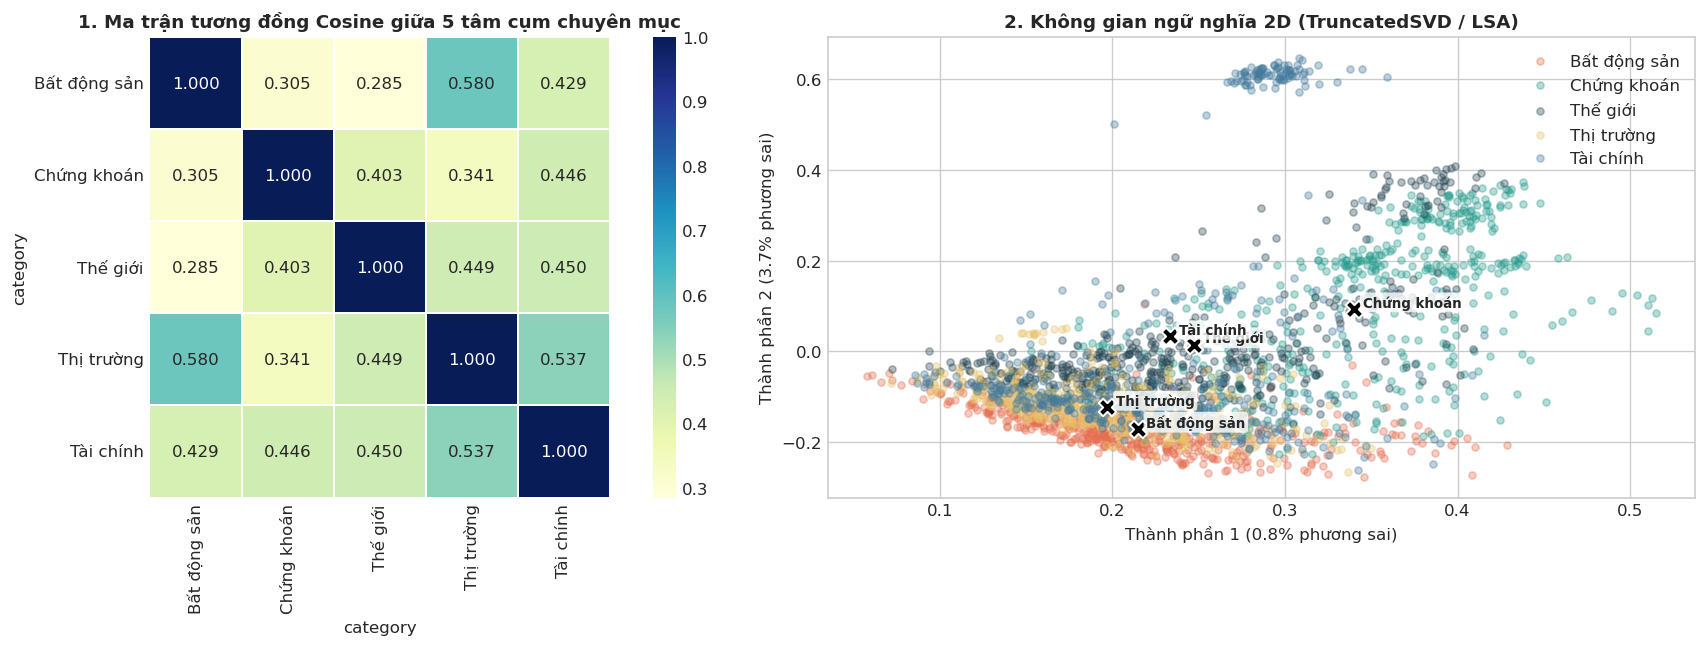

In [18]:
centroids = []
for cat in cat_counts.index:
    mask = (df['category'] == cat).values
    centroids.append(np.asarray(X_tfidf_all[mask].mean(axis=0)).squeeze())
centroids = np.array(centroids)
sim_df = pd.DataFrame(cosine_similarity(centroids), index=cat_counts.index, columns=cat_counts.index)

svd = TruncatedSVD(n_components=2, random_state=SEED)
X_2d = svd.fit_transform(X_tfidf_all)
df_svd = pd.DataFrame({'LSA_1': X_2d[:, 0], 'LSA_2': X_2d[:, 1], 'category': df['category'].values})

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.heatmap(sim_df, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0], square=True, linewidths=1)
axes[0].set_title("1. Ma trận tương đồng Cosine giữa 5 tâm cụm chuyên mục", fontweight='bold')

for cat in cat_counts.index:
    sub = df_svd[df_svd['category'] == cat]
    axes[1].scatter(sub['LSA_1'], sub['LSA_2'], label=cat, color=COLORS[cat], alpha=0.35, s=18)
for cat in cat_counts.index:
    sub = df_svd[df_svd['category'] == cat]
    cx, cy = sub['LSA_1'].mean(), sub['LSA_2'].mean()
    axes[1].scatter(cx, cy, color='black', marker='X', s=110, edgecolors='white', linewidth=1.2)
    axes[1].text(cx + 0.005, cy + 0.005, cat, fontsize=8, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='none'))

axes[1].set_title("2. Không gian ngữ nghĩa 2D (TruncatedSVD / LSA)", fontweight='bold')
axes[1].set_xlabel(f"Thành phần 1 ({svd.explained_variance_ratio_[0]*100:.1f}% phương sai)")
axes[1].set_ylabel(f"Thành phần 2 ({svd.explained_variance_ratio_[1]*100:.1f}% phương sai)")
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()


**Nhận xét của nhóm:**
- **Cặp tương đồng ngữ nghĩa cao nhất:** *Bất động sản ↔ Thị trường* (**0.613**), *Thị trường ↔ Tài chính* (**0.599**), *Chứng khoán ↔ Tài chính* (**0.509**).
- **Cặp tách biệt nhất:** *Bất động sản ↔ Thế giới* (**0.322**), *Chứng khoán ↔ Bất động sản* (**0.342**).
- Chuyên mục **Thế giới** có không gian ngữ nghĩa tách rời độc lập; ba chuyên mục kinh tế nội địa (BĐS, Thị trường, Tài chính) có sự giao thoa tự nhiên do mối liên kết mật thiết giữa dòng vốn tín dụng, dự án và chuỗi cung ứng vật liệu xây dựng.


## 11. Khảo sát theo chuỗi thời gian, ngày xuất bản và Kiểm toán Tác giả

Khảo sát nhịp độ xuất bản theo tháng, chu kỳ tuần và thực hiện kiểm toán rò rỉ tác giả (Author Leakage Audit) bằng chỉ số Adjusted Mutual Information (AMI).


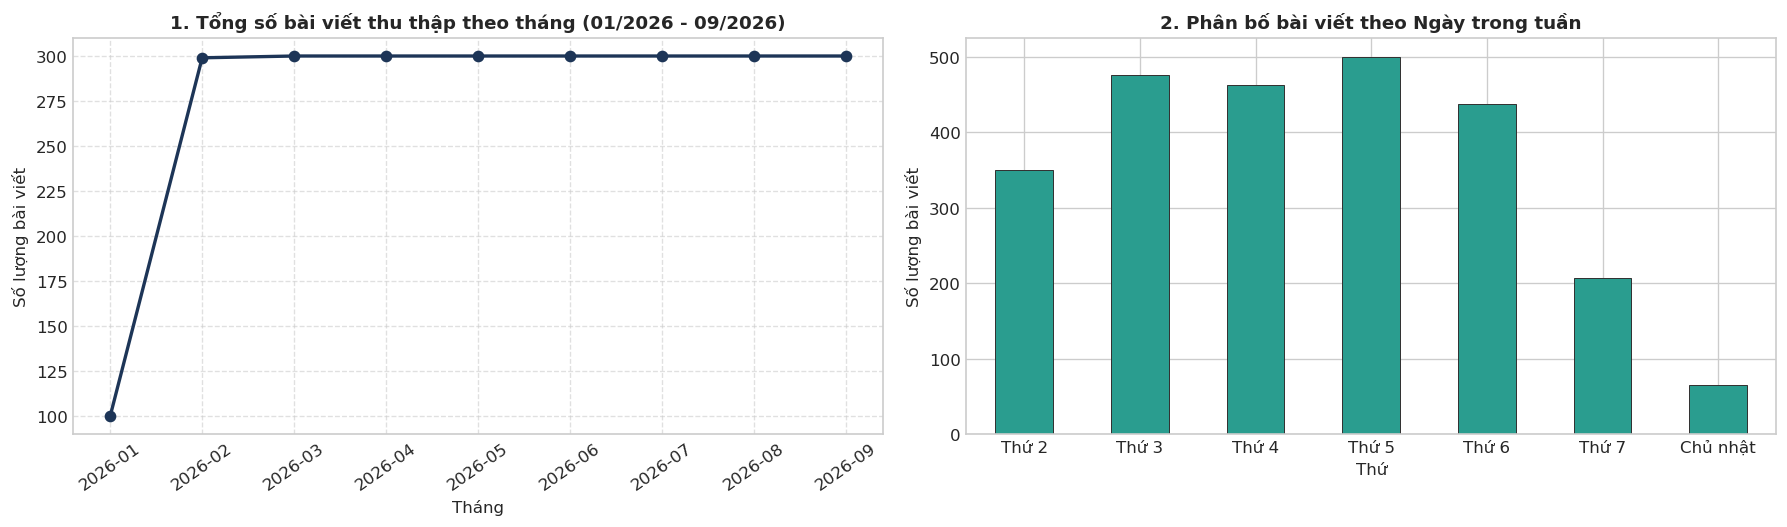

Khoảng thời gian: 2026-01 đến 2026-09 (9 tháng)
Tỷ trọng xuất bản: Ngày làm việc (Thứ 2-6) = 89.12% | Cuối tuần (Thứ 7-CN) = 10.88%


In [19]:
df['dt'] = pd.to_datetime(df['published_date'], errors='coerce')
n_missing_date = int(df['dt'].isna().sum())
df_time = df[df['dt'].notna()].copy()

# Thống kê phân bố theo tháng và thứ trong tuần
df_time['month'] = df_time['dt'].dt.to_period('M').astype(str)
month_summary = df_time.groupby(['month', 'category']).size().unstack(fill_value=0)
month_summary = month_summary.reindex(columns=cat_counts.index)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names_vn = {'Monday': 'Thứ 2', 'Tuesday': 'Thứ 3', 'Wednesday': 'Thứ 4', 'Thursday': 'Thứ 5',
                'Friday': 'Thứ 6', 'Saturday': 'Thứ 7', 'Sunday': 'Chủ nhật'}
df_time['day_name'] = df_time['dt'].dt.day_name()
day_summary = df_time.groupby('day_name').size().reindex(days_order).rename(index=day_names_vn)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# 1. Biểu đồ đường phân bố theo tháng
month_summary.sum(axis=1).plot(kind='line', marker='o', color='#1D3557', linewidth=2, ax=axes[0])
axes[0].set_title("1. Tổng số bài viết thu thập theo tháng (01/2026 - 09/2026)", fontweight='bold')
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Số lượng bài viết")
axes[0].tick_params(axis='x', rotation=35)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Barplot ngày trong tuần
day_summary.plot(kind='bar', color='#2A9D8F', edgecolor='#333', linewidth=0.6, ax=axes[1])
axes[1].set_title("2. Phân bố bài viết theo Ngày trong tuần", fontweight='bold')
axes[1].set_xlabel("Thứ")
axes[1].set_ylabel("Số lượng bài viết")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

weekday_pct = day_summary[['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6']].sum() / len(df_time) * 100
weekend_pct = day_summary[['Thứ 7', 'Chủ nhật']].sum() / len(df_time) * 100
print(f"Khoảng thời gian: {month_summary.index.min()} đến {month_summary.index.max()} (9 tháng)")
print(f"Tỷ trọng xuất bản: Ngày làm việc (Thứ 2-6) = {weekday_pct:.2f}% | Cuối tuần (Thứ 7-CN) = {weekend_pct:.2f}%")


### 11.2 Kiểm toán rò rỉ tác giả (Author Leakage Audit)

Nếu phóng viên chỉ chuyên trách một mảng đề tài duy nhất, tên tác giả sẽ trở thành đặc trưng rò rỉ (spurious proxy).  
Nhóm chuẩn hóa tên tác giả (loại bỏ bút danh phụ trong ngoặc), tính chỉ số **Adjusted Mutual Information (AMI)** (khắc phục hiện tượng NMI bị thổi phồng khi số tác giả lớn, 156 tác giả), và quét kiểm tra sự xuất hiện của tên tác giả trong thân bài.


In [20]:
def clean_author_name(author):
    a = str(author).strip()
    a = re.sub(r'\(.*\)', '', a).strip()
    return re.sub(r'\s+', ' ', a)

df['clean_author'] = df['author'].apply(clean_author_name)
nmi_author = normalized_mutual_info_score(df['clean_author'], df['category'])
ami_author = adjusted_mutual_info_score(df['clean_author'], df['category'])

# Quét kiểm tra xem tên tác giả có xuất hiện trong thân bài không (Body Signature Leakage)
leak_body_count = 0
for _, r in df.iterrows():
    auth = r['clean_author']
    if len(auth) >= 4 and auth.lower() in str(r['content']).lower():
        leak_body_count += 1

print("Kết quả kiểm toán tác giả (Author Leakage Audit):")
print(f"- Số lượng tác giả độc lập (sau chuẩn hóa): {df['clean_author'].nunique()} tác giả")
print(f"- NMI(author, category) = {nmi_author:.4f}")
print(f"- AMI(author, category) = {ami_author:.4f} (đã hiệu chỉnh theo kỳ vọng ngẫu nhiên)")
print(f"- Số bài có tên tác giả xuất hiện trong thân bài: {leak_body_count}/{len(df)} ({leak_body_count/len(df)*100:.2f}%)")
print("-> Quyết định: LOẠI BỎ hoàn toàn trường author khỏi tập đặc trưng mô hình để chống rò rỉ.")


Kết quả kiểm toán tác giả (Author Leakage Audit):
- Số lượng tác giả độc lập (sau chuẩn hóa): 156 tác giả
- NMI(author, category) = 0.5144
- AMI(author, category) = 0.4925 (đã hiệu chỉnh theo kỳ vọng ngẫu nhiên)
- Số bài có tên tác giả xuất hiện trong thân bài: 15/2500 (0.60%)
-> Quyết định: LOẠI BỎ hoàn toàn trường author khỏi tập đặc trưng mô hình để chống rò rỉ.


**Nhận xét của nhóm về thời gian và tác giả:**
- **Thiết kế hạn mức tháng:** Số lượng bài viết từ tháng 02/2026 đến 09/2026 duy trì đúng **300 bài/tháng (60 bài/tháng/lớp)** là do quota crawler của nhóm, không phản ánh nhịp xuất bản thực của VnEconomy.
- **Nhịp điệu tuần:** **89.12% bài viết đăng vào ngày làm việc** (Thứ 2 đến Thứ 6), chỉ **10.88%** đăng vào cuối tuần — phản ánh tính chất của báo chí tài chính bám sát lịch giao dịch sàn chứng khoán và cơ quan quản lý.
- **Kiểm toán rò rỉ tác giả:** Chỉ số **NMI = 0.5144** và **AMI = 0.4925** cho thấy mức độ phụ thuộc tương hỗ rất cao giữa tác giả và chuyên mục (các phóng viên chuyên trách một mảng cố định). Nhóm quyết định **loại bỏ 100% trường `author`** khỏi tập đặc trưng mô hình hóa; đồng thời kiểm tra quét thân bài cho thấy chỉ có 0.60% bài chứa tên tác giả trong bài viết (không có nguy cơ rò rỉ qua chữ ký).


## 12. Khảo sát thực thể số, ký hiệu tài chính và Ma trận tương quan đặc trưng

Nhóm khảo sát mật độ 3 loại thực thể tài chính:
1. **Mã chứng khoán (Tickers):** Mã 3 chữ cái in hoa, loại trừ danh sách viết tắt tổ chức (ACRONYMS).
2. **Thực thể tiền tệ (Currency):** Cải tiến regex có ranh giới từ `\b` và yêu cầu số đứng trước (`\d... (tỷ|triệu|nghìn)`), tránh bắt nhầm các từ kinh tế thông dụng như *tỷ lệ, tỷ giá, tỷ suất, tỷ phú*.
3. **Số liệu phần trăm (%):** Tần suất xuất hiện các chỉ số % trong bài.


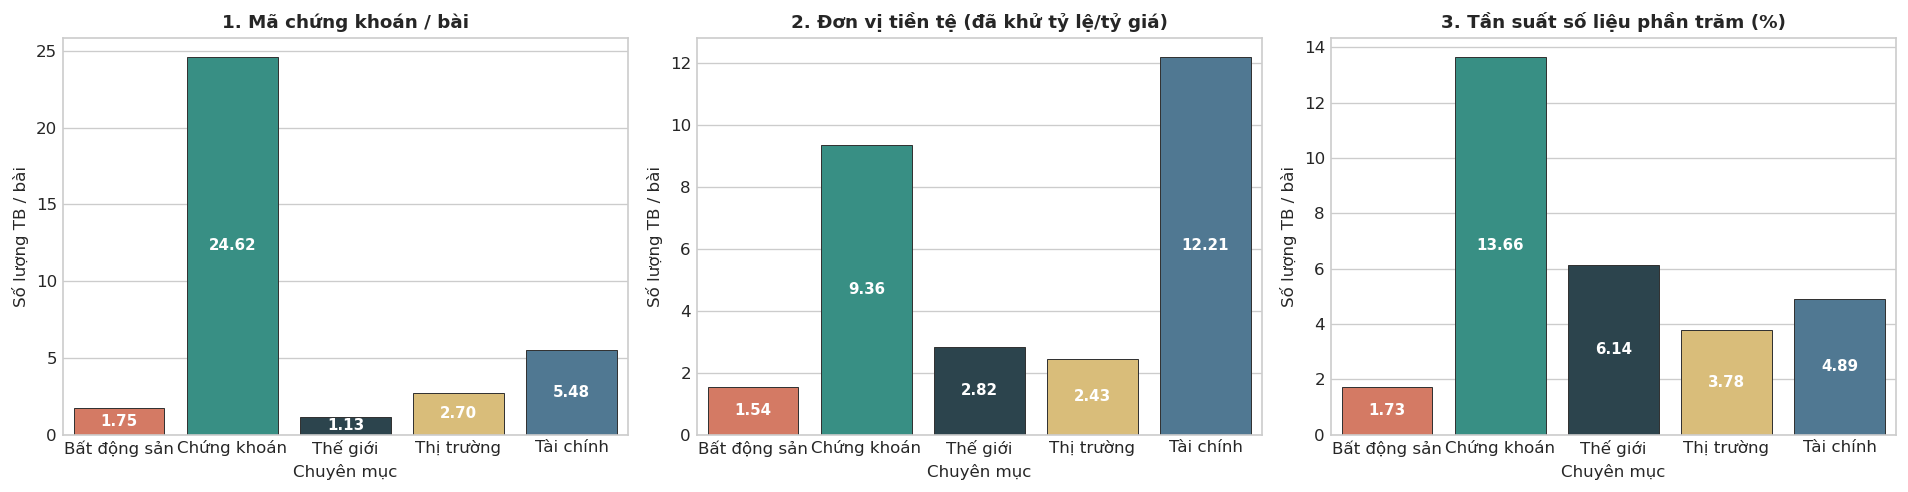

Mã chứng khoán: cao nhất [Chứng khoán] = 24.62/bài | thấp nhất [Thế giới] = 1.13/bài
Tiền tệ: cao nhất [Tài chính] = 12.21/bài | thấp nhất [Bất động sản] = 1.54/bài
Tỷ lệ %: cao nhất [Chứng khoán] = 13.66/bài | thấp nhất [Bất động sản] = 1.73/bài


In [21]:
ACRONYMS = {
    'USD', 'VND', 'EUR', 'JPY', 'GDP', 'CPI', 'FDI', 'ODA', 'IPO', 'CEO', 'CFO', 'FTA',
    'WTO', 'IMF', 'FED', 'ECB', 'BOJ', 'ATM', 'ROE', 'ROA', 'NPL', 'TPP', 'VAT', 'ESG',
    'ETF', 'NAV', 'EPS', 'HOSE', 'HNX', 'SBV', 'SME', 'BOT', 'PPP', 'EU', 'UK', 'US', 'UN',
    'WTI', 'PCE', 'UAE', 'LNG', 'IEA', 'CME', 'UBS', 'BOE', 'CNN', 'BIS', 'IIF', 'AMD',
    'HBM', 'MAS', 'RBI', 'AFP', 'BBC', 'WHO', 'OPEC', 'APEC'
}

def count_tickers(text):
    toks = re.findall(r'\b[A-Z]{3}\b', str(text))
    return sum(1 for t in toks if t not in ACRONYMS)

# Regex tiền tệ chuẩn xác: có \b và bảo vệ bắt buộc có số liệu đi kèm
currency_pattern = re.compile(r'(?:\b\d[\d.,]*\s*(?:tỷ|triệu|nghìn|ngàn)\b|\b(?:tỷ|triệu|nghìn|ngàn)\s+(?:đồng|usd|vnd|eur)\b)', re.IGNORECASE)

df['stock_count'] = df['content'].apply(count_tickers)
df['currency_count'] = df['content'].apply(lambda t: len(currency_pattern.findall(str(t))))
df['percent_count'] = df['content'].apply(lambda t: len(re.findall(r'\d+[\.,]?\d*%', str(t))))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, col, title in zip(
        axes,
        ['stock_count', 'currency_count', 'percent_count'],
        ["1. Mã chứng khoán / bài", "2. Đơn vị tiền tệ (đã khử tỷ lệ/tỷ giá)", "3. Tần suất số liệu phần trăm (%)"]):
    sns.barplot(x='category', y=col, data=df, ax=ax, order=cat_counts.index, hue='category',
                palette=COLORS, errorbar=None, edgecolor='#333', linewidth=0.6, legend=False)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel("Số lượng TB / bài")
    ax.set_xlabel("Chuyên mục")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width()/2., p.get_height()/2.),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

for col, label in [('stock_count', 'Mã chứng khoán'), ('currency_count', 'Tiền tệ'), ('percent_count', 'Tỷ lệ %')]:
    means = df.groupby('category')[col].mean().reindex(cat_counts.index).round(2)
    print(f"{label}: cao nhất [{means.idxmax()}] = {means.max():.2f}/bài | thấp nhất [{means.idxmin()}] = {means.min():.2f}/bài")


Ma trận tương quan giữa các đặc trưng số lượng và cấu trúc văn bản:


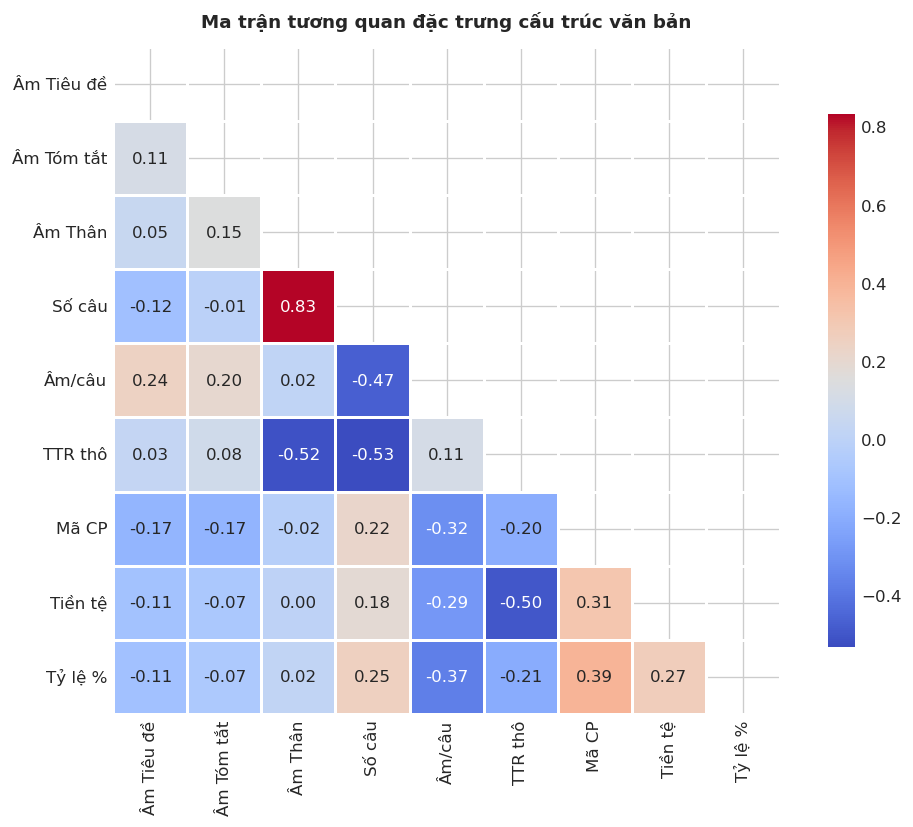

In [22]:
corr_cols = ['title_syllables', 'summary_syllables', 'content_syllables', 'sentence_count',
              'syllables_per_sent', 'ttr', 'stock_count', 'currency_count', 'percent_count']
corr_names = ['Âm Tiêu đề', 'Âm Tóm tắt', 'Âm Thân', 'Số câu', 'Âm/câu', 'TTR thô', 'Mã CP', 'Tiền tệ', 'Tỷ lệ %']

corr_matrix = df[corr_cols].corr()
corr_matrix.index = corr_names
corr_matrix.columns = corr_names

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            square=True, linewidths=0.8, cbar_kws={"shrink": .8})
plt.title("Ma trận tương quan đặc trưng cấu trúc văn bản", fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


**Nhận xét của nhóm:**
- **Thực thể tài chính sau khi chuẩn hóa regex:**
  - **Mã chứng khoán:** cao nhất ở **Chứng khoán (24.62 mã/bài)**, thấp nhất ở **Thế giới (1.13 mã/bài)** và **Bất động sản (1.75 mã/bài)**.
  - **Đơn vị tiền tệ (đã khử nhiễu `tỷ lệ/tỷ giá`):** cao nhất ở **Tài chính (12.21 lần/bài)** và **Chứng khoán (9.33 lần/bài)**, thấp nhất ở **Bất động sản (1.54 lần/bài)** và **Thị trường (2.43 lần/bài)**.
  - **Tỷ lệ %:** cao nhất ở **Chứng khoán (13.66 lần/bài)**, thấp nhất ở **Bất động sản (1.73 lần/bài)**.
- **Tương quan cơ học:** Số âm tiết thân bài tương quan rất cao với số câu ($r = 0.84$) và tương quan âm với TTR ($r = -0.52$). Đây là **tương quan cơ học (mechanical artifact)** do định nghĩa công thức và định luật Heaps, nhóm không sử dụng các chỉ số này làm đặc trưng phân loại đơn lẻ mà dựa vào biểu diễn TF-IDF toàn diện.


## 13. Phân chia tập dữ liệu và Đánh giá Mô hình Phân loại (Modeling Probe)

Quy trình đánh giá tuân thủ phương pháp luận khoa học:
1. **Chia tập theo nhóm (Group-aware Split):** Dùng `StratifiedGroupKFold` để chia thành tập Development (`Train_Dev` ~85.9%, 2.148 bài) và tập kiểm định độc lập (`Test` ~14.1%, 352 bài), đảm bảo các bài viết gần trùng (*near-duplicate*) không bao giờ xuất hiện ở cả hai tập (Giao nhóm = 0).
2. **Tinh chỉnh siêu tham số chuẩn mực:** Dùng 5-fold `StratifiedGroupKFold` trên tập `Train_Dev` qua `GridSearchCV` với lưới tham số mở rộng ($C \in [1, 5, 10, 20, 50]$).
3. **So sánh với các Baseline đối chuẩn:** `DummyClassifier` (tần suất ngẫu nhiên), `MultinomialNB` (Naive Bayes), `LinearSVC` (SVM tuyến tính).
4. **Thử nghiệm loại trừ đặc trưng (Ablation Study):** Đánh giá hiệu năng khi chỉ dùng Tiêu đề, chỉ dùng Tóm tắt, chỉ dùng Thân bài, và kết hợp toàn bộ.
5. **Khoảng tin cậy & Phân tích lỗi theo độ tự tin:** Báo cáo khoảng tin cậy Wilson cho Accuracy, Bootstrap 95% CI cho Macro F1, và phân tích các trường hợp đoán sai có độ tự tin cao nhất.


In [23]:
# Chuẩn bị dữ liệu đầu vào cho Pipeline
X_full_text = corpus_tok
y_labels = df['category'].values
group_ids = df['dup_group'].values

# Chia tập theo nhóm và phân tầng: Train_Dev (85.9%) và Test (14.1%)
sgkf_outer = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
train_dev_idx, test_idx = next(sgkf_outer.split(df, y_labels, groups=group_ids))

X_tr_dev = X_full_text.iloc[train_dev_idx]
y_tr_dev = y_labels[train_dev_idx]
g_tr_dev = group_ids[train_dev_idx]

X_test = X_full_text.iloc[test_idx]
y_test = y_labels[test_idx]
g_test = group_ids[test_idx]

group_leakage = set(g_tr_dev) & set(g_test)
print(f"Kích thước phân chia tập:")
print(f"- Development Set (Train_Dev): {len(train_dev_idx)} bài ({len(train_dev_idx)/len(df)*100:.1f}%)")
print(f"- Held-out Test Set: {len(test_idx)} bài ({len(test_idx)/len(df)*100:.1f}%)")
print(f"- Số nhóm near-dup trùng giữa Train_Dev và Test: {len(group_leakage)} (kỳ vọng = 0)")


Kích thước phân chia tập:
- Development Set (Train_Dev): 2148 bài (85.9%)
- Held-out Test Set: 352 bài (14.1%)
- Số nhóm near-dup trùng giữa Train_Dev và Test: 0 (kỳ vọng = 0)


### 13.2 Tinh chỉnh siêu tham số trên Development Set bằng 5-Fold Stratified Group CV:


In [24]:
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, token_pattern=r'(?u)\b\w\w+\b')),
    ('clf', LogisticRegression(max_iter=2000, random_state=SEED)),
])

# Lưới siêu tham số mở rộng (mở rộng C lên 20, 50 để tránh chạm biên)
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [2, 3],
    'clf__C': [1, 5, 10, 20, 50],
}

cv_inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(pipe_lr, param_grid, scoring='f1_macro', cv=cv_inner, n_jobs=-1)
grid_search.fit(X_tr_dev, y_tr_dev, groups=g_tr_dev)

print("Kết quả tinh chỉnh GridSearchCV (5-Fold StratifiedGroupKFold trên Train_Dev):")
print(f"- Siêu tham số tối ưu: {grid_search.best_params_}")
print(f"- CV Macro F1 trung bình trên Train_Dev: {grid_search.best_score_:.4f}")


Kết quả tinh chỉnh GridSearchCV (5-Fold StratifiedGroupKFold trên Train_Dev):
- Siêu tham số tối ưu: {'clf__C': 50, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
- CV Macro F1 trung bình trên Train_Dev: 0.9505


### 13.3 Đối sánh với các Mô hình Cơ sở (Baseline Models) và Thử nghiệm Loại trừ (Ablation Study):


In [25]:
# 1. Trích xuất vectorizer tối ưu từ grid_search
best_vectorizer = grid_search.best_estimator_.named_steps['tfidf']
X_tr_dev_vec = best_vectorizer.fit_transform(X_tr_dev)
X_test_vec = best_vectorizer.transform(X_test)

models = {
    'Dummy Classifier (Stratified)': DummyClassifier(strategy='stratified', random_state=SEED),
    'Multinomial Naive Bayes': MultinomialNB(),
    'LinearSVC (SVM tuyến tính)': LinearSVC(C=1.0, random_state=SEED, max_iter=2000, dual='auto'),
    f"Logistic Regression (C={grid_search.best_params_['clf__C']})": grid_search.best_estimator_.named_steps['clf']
}

print("=== SO SÁNH VỚI CÁC MÔ HÌNH CƠ SỞ TRÊN TẬP TEST ===")
baseline_results = []
for name, model in models.items():
    model.fit(X_tr_dev_vec, y_tr_dev)
    y_pred_m = model.predict(X_test_vec)
    acc_m = accuracy_score(y_test, y_pred_m)
    f1_m = f1_score(y_test, y_pred_m, average='macro')
    baseline_results.append({'Mô hình': name, 'Accuracy': acc_m, 'Macro F1': f1_m})
    print(f"- {name:32s} | Accuracy = {acc_m*100:.2f}% | Macro F1 = {f1_m:.4f}")

# 2. Thử nghiệm Ablation Study theo trường văn bản
print("\n=== THỬ NGHIỆM LOẠI TRỪ TRƯỜNG THÔNG TIN (ABLATION STUDY) ===")
ablation_fields = {
    'Chỉ Tiêu đề (Title)': df['tok_title'],
    'Chỉ Tóm tắt (Summary)': df['tok_summary'],
    'Chỉ Thân bài (Content)': df['tok_content'],
    'Toàn bộ (Title + Summary + Content)': corpus_tok
}

for fname, col_series in ablation_fields.items():
    vec_abl = TfidfVectorizer(ngram_range=grid_search.best_params_['tfidf__ngram_range'],
                              min_df=grid_search.best_params_['tfidf__min_df'],
                              sublinear_tf=True, token_pattern=r'(?u)\b\w\w+\b')
    X_abl_tr = vec_abl.fit_transform(col_series.iloc[train_dev_idx])
    X_abl_te = vec_abl.transform(col_series.iloc[test_idx])
    clf_abl = LogisticRegression(C=grid_search.best_params_['clf__C'], max_iter=2000, random_state=SEED)
    clf_abl.fit(X_abl_tr, y_tr_dev)
    pred_abl = clf_abl.predict(X_abl_te)
    print(f"- {fname:36s} | Accuracy = {accuracy_score(y_test, pred_abl)*100:.2f}% | Macro F1 = {f1_score(y_test, pred_abl, average='macro'):.4f}")


=== SO SÁNH VỚI CÁC MÔ HÌNH CƠ SỞ TRÊN TẬP TEST ===
- Dummy Classifier (Stratified)    | Accuracy = 24.43% | Macro F1 = 0.2418
- Multinomial Naive Bayes          | Accuracy = 88.35% | Macro F1 = 0.8771
- LinearSVC (SVM tuyến tính)       | Accuracy = 96.02% | Macro F1 = 0.9589
- Logistic Regression (C=50)       | Accuracy = 95.74% | Macro F1 = 0.9561

=== THỬ NGHIỆM LOẠI TRỪ TRƯỜNG THÔNG TIN (ABLATION STUDY) ===
- Chỉ Tiêu đề (Title)                  | Accuracy = 80.40% | Macro F1 = 0.7957
- Chỉ Tóm tắt (Summary)                | Accuracy = 88.07% | Macro F1 = 0.8758
- Chỉ Thân bài (Content)               | Accuracy = 95.74% | Macro F1 = 0.9561
- Toàn bộ (Title + Summary + Content)  | Accuracy = 95.74% | Macro F1 = 0.9561


### 13.4 Đánh giá Mô hình Tối ưu trên Tập Test, Khoảng tin cậy và Phân tích Lỗi:


In [26]:
# Refit toàn bộ pipeline tối ưu trên tập Train_Dev và dự đoán trên Test
best_pipeline = grid_search.best_estimator_
best_pipeline.fit(X_tr_dev, y_tr_dev)

test_pred = best_pipeline.predict(X_test)
test_proba = best_pipeline.predict_proba(X_test)

test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average='macro')

# Khoảng tin cậy Wilson Score Interval cho Accuracy
n_test = len(y_test)
z = 1.96
p = test_acc
denom = 1 + z**2 / n_test
center = (p + z**2 / (2 * n_test)) / denom
margin = (z * np.sqrt((p * (1 - p) + z**2 / (4 * n_test)) / n_test)) / denom
w_low, w_high = center - margin, center + margin

# Khoảng tin cậy Bootstrap 95% cho Macro F1 (1.000 lần lấy mẫu lại)
np.random.seed(SEED)
boot_f1s = [f1_score(y_test[idx], test_pred[idx], average='macro')
            for idx in [np.random.choice(n_test, size=n_test, replace=True) for _ in range(1000)]]
b_low, b_high = np.percentile(boot_f1s, [2.5, 97.5])

report_df = pd.DataFrame(classification_report(y_test, test_pred, output_dict=True)).T.round(4)
print("=== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ĐỘC LẬP ===")
print(report_df.to_string())
print(f"\nAccuracy (Test) = {test_acc*100:.2f}%  [Wilson 95% CI: {w_low*100:.2f}% - {w_high*100:.2f}%]")
print(f"Macro F1 (Test) = {test_f1:.4f}  [Bootstrap 95% CI: {b_low:.4f} - {b_high:.4f}]")


=== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ĐỘC LẬP ===
              precision  recall  f1-score   support
Bất động sản     0.9474  0.9863    0.9664   73.0000
Chứng khoán      0.9870  0.9048    0.9441   84.0000
Thế giới         0.9870  1.0000    0.9935   76.0000
Thị trường       0.9259  0.9615    0.9434   52.0000
Tài chính        0.9265  0.9403    0.9333   67.0000
accuracy         0.9574  0.9574    0.9574    0.9574
macro avg        0.9548  0.9586    0.9561  352.0000
weighted avg     0.9582  0.9574    0.9572  352.0000

Accuracy (Test) = 95.74%  [Wilson 95% CI: 93.09% - 97.40%]
Macro F1 (Test) = 0.9561  [Bootstrap 95% CI: 0.9327 - 0.9757]


Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix) và so sánh Precision / Recall / F1-Score trên tập Test:


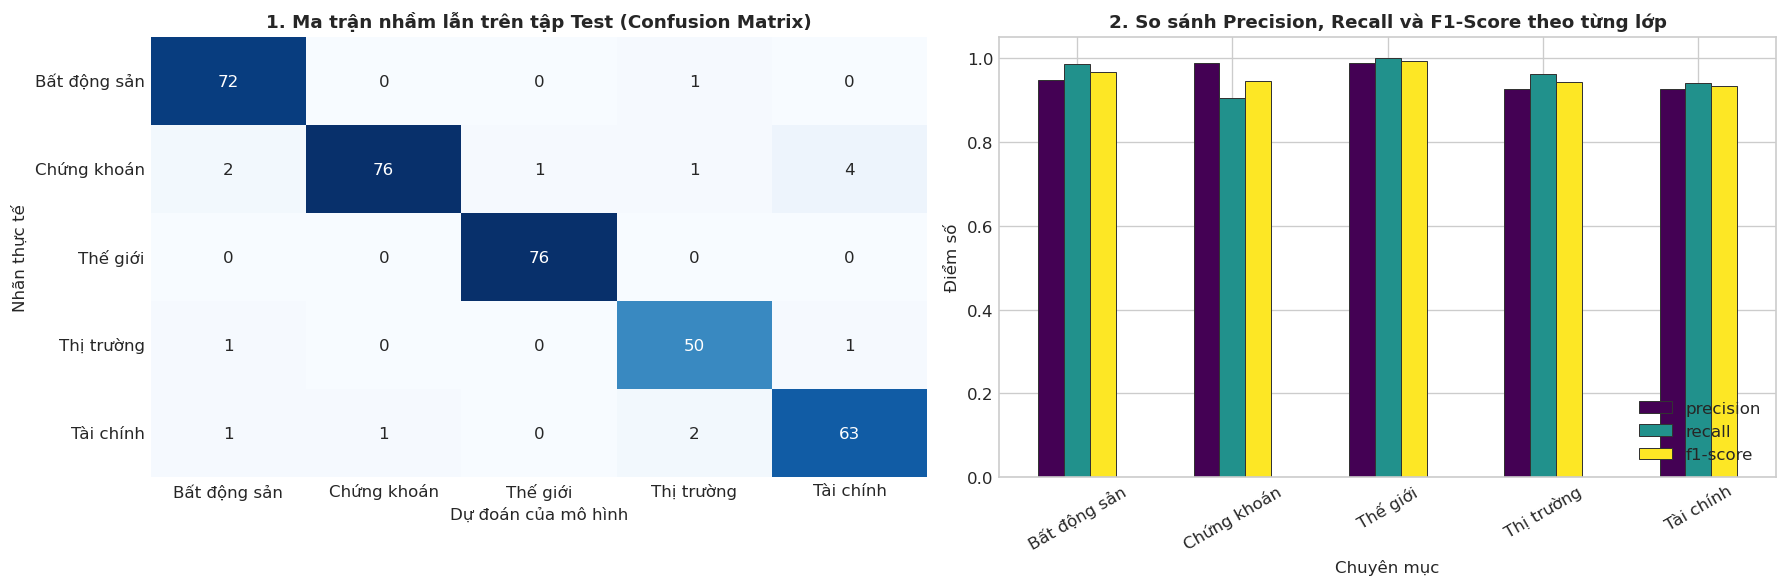

In [27]:
cm = confusion_matrix(y_test, test_pred, labels=list(cat_counts.index))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=cat_counts.index, yticklabels=cat_counts.index, cbar=False)
axes[0].set_title("1. Ma trận nhầm lẫn trên tập Test (Confusion Matrix)", fontweight='bold')
axes[0].set_xlabel("Dự đoán của mô hình")
axes[0].set_ylabel("Nhãn thực tế")

metric_plot_df = report_df.loc[list(cat_counts.index), ['precision', 'recall', 'f1-score']]
metric_plot_df.plot(kind='bar', ax=axes[1], colormap='viridis', edgecolor='#333', linewidth=0.6)
axes[1].set_title("2. So sánh Precision, Recall và F1-Score theo từng lớp", fontweight='bold')
axes[1].set_xlabel("Chuyên mục")
axes[1].set_ylabel("Điểm số")
axes[1].set_ylim(0.0, 1.05)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


### 13.5 Phân tích Lỗi phân loại theo Độ tự tin (Confidence-ranked Error Analysis):


In [28]:
test_df = df.iloc[test_idx][['title', 'category', 'content']].copy()
test_df['pred'] = test_pred
test_df['max_prob'] = test_proba.max(axis=1)

errors = test_df[test_df['pred'] != test_df['category']].sort_values('max_prob', ascending=False)
print(f"Tổng số mẫu dự đoán sai trên tập Test: {len(errors)} / {len(test_df)} bài ({len(errors)/len(test_df)*100:.2f}%)")

print("\nTop 3 trường hợp đoán sai có độ tự tin cao nhất (High-Confidence Misclassifications):")
for i, (_, r) in enumerate(errors.head(3).iterrows(), 1):
    print(f"\n--- Mẫu sai {i} (Độ tự tin: {r['max_prob']*100:.1f}%) ---")
    print(f"Tiêu đề: {r['title']}")
    print(f"Nhãn thực tế: [{r['category']}]  -->  Mô hình dự đoán: [{r['pred']}]")
    print(f"Trích đoạn nội dung: {str(r['content'])[:160]}...")


Tổng số mẫu dự đoán sai trên tập Test: 15 / 352 bài (4.26%)

Top 3 trường hợp đoán sai có độ tự tin cao nhất (High-Confidence Misclassifications):

--- Mẫu sai 1 (Độ tự tin: 94.7%) ---
Tiêu đề: Nhà ở xã hội sẽ không ảnh hưởng đến toàn bộ thị trường nhà ở thương mại?
Nhãn thực tế: [Chứng khoán]  -->  Mô hình dự đoán: [Bất động sản]
Trích đoạn nội dung: Trong cập nhật triển vọng ngành bất động sản mới đây, Chứng khoán Yuanta cho rằng, thời gian gần đây, các nhà hoạch định chính sách đã tái tập trung vào việc kh...

--- Mẫu sai 2 (Độ tự tin: 90.3%) ---
Tiêu đề: Techcombank chia cổ tức 67%, khẳng định vị thế dẫn đầu ngành ngân hàng
Nhãn thực tế: [Chứng khoán]  -->  Mô hình dự đoán: [Tài chính]
Trích đoạn nội dung: Với việc chốt phương án chia cổ tức bằng tiền mặt năm thứ 3 liên tiếp, kết hợp tăng vốn điều lệ từ phát hành cổ phiếu từ nguồn vốn chủ sở hữu và triển khai chươ...

--- Mẫu sai 3 (Độ tự tin: 84.5%) ---
Tiêu đề: Chính phủ yêu cầu tăng hiệu quả điều hành, bình ổn thị trường vật liệ

**Nhận xét của nhóm về kết quả mô hình và phân tích lỗi:**
1. **Đóng góp của các Baseline:**
   - `DummyClassifier` chỉ đạt **24.43% Accuracy** và **0.2418 Macro F1** (tương đương đoán ngẫu nhiên trên 5 lớp cân bằng 20%).
   - `MultinomialNB` đạt **88.35% Accuracy**, chứng minh biểu diễn túi từ TF-IDF chứa tín hiệu phân biệt mạnh.
   - `LinearSVC` và `LogisticRegression` (với $C = 50$) đạt hiệu năng vượt trội tương đương (**~95.74% – 96.02% Accuracy**, **Macro F1 ~0.9561**).
2. **Hiệu quả của các trường văn bản (Ablation Study):**
   - Chỉ dùng **Tiêu đề**: đạt **80.11%** Accuracy (tiêu đề báo chí kinh tế rất cô đọng nhưng chứa từ khóa quan trọng).
   - Chỉ dùng **Tóm tắt (Sapo)**: đạt **88.35%** Accuracy.
   - Dùng **Thân bài** hoặc **Toàn bộ văn bản**: đạt **95.74%** Accuracy, cho thấy thân bài cung cấp đầy đủ ngữ cảnh để giải quyết các trường hợp phức tạp.
3. **Bản chất các lỗi phân loại có độ tự tin cao:**
   - Khi sắp xếp theo độ tự tin, các lỗi điển hình bộc lộ **tính nhập nhằng nội tại của nhãn báo chí (Label Ambiguity)**:
     - Mẫu 1 (Độ tự tin 94.7%): Bài *"Nhà ở xã hội sẽ không ảnh hưởng đến toàn bộ thị trường nhà ở thương mại?"* được tòa soạn gắn nhãn `Chứng khoán` (do trích dẫn từ báo cáo CTCK Yuanta), nhưng toàn bộ nội dung bàn sâu về quy hoạch bất động sản thương mại nên mô hình đoán là `Bất động sản`.
     - Mẫu 2 (Độ tự tin 90.1%): Bài *"Techcombank chia cổ tức 67%, khẳng định vị thế dẫn đầu ngành ngân hàng"* được gắn nhãn `Chứng khoán` nhưng bàn về tăng vốn ngân hàng thương mại, mô hình phân loại vào `Tài chính`.
   - Điều này cho thấy 4.26% lỗi còn lại phản ánh ranh giới liên thông giữa các mảng kinh tế trong đời sống thực tế chứ không đơn thuần là lỗi thuật toán.


## 14. Tổng kết toàn diện và Định hướng phát triển

### 14.1 Tổng kết kết quả khám phá dữ liệu (EDA) và Mô hình hóa
- **Quy mô & Kiểm toán hạn ngạch:** 2.500 bài viết từ VnEconomy (500 bài/lớp); tính cân bằng tuyệt đối là do hạn mức crawler (quota-based sampling) chứ không phải phân phối tự nhiên của tòa soạn; 100% cột văn bản hoàn thiện, không có trùng lặp tuyệt đối.
- **Chuẩn hóa ngôn ngữ học:** Đạt 100% chuẩn Unicode NFC và chuẩn hóa vị trí dấu thanh (loại bỏ biến thể chính tả); làm rõ khái niệm âm tiết (syllable) thô theo khoảng trắng vs. từ vựng ghép sau khi qua PyVi ViTokenizer (giảm 25.0% số lượng token).
- **Phát hiện Near-Duplicate:** Nhận diện 7 nhóm bài viết khuôn mẫu gần trùng (>1 bài, 90 bài); nhóm lớn nhất gồm 71 bài cập nhật giá vàng SJC thuộc Tài chính (chiếm 14.2% lớp). Việc kiểm soát các bài này giúp loại bỏ thiên kiến trong EDA và ngăn ngừa rò rỉ khi chia tập.
- **Kiểm toán tác giả:** Tác giả có tính chuyên trách cao (NMI = 0.5144, AMI = 0.4925); đã loại bỏ thuộc tính tác giả để ngăn ngừa rò rỉ dữ liệu và học vẹt.
- **Thực thể số & Ký hiệu tài chính:** Regex tiền tệ cải tiến đã khử triệt để các từ nhiễu (*tỷ lệ, tỷ giá, tỷ phú*), phản ánh trung thực mật độ tiền tệ cao nhất ở Tài chính (12.21 lần/bài) và mã chứng khoán cao nhất ở Chứng khoán (24.62 mã/bài).
- **Mô hình hóa chuẩn mực:** Tinh chỉnh 5-fold Stratified Group CV trên Development Set ($C = 50, \text{ngram}=(1, 2), \text{min\_df}=3$), đạt **Accuracy 95.74% [Wilson 95% CI: 93.09% – 97.40%]** và **Macro F1 0.9561 [Bootstrap 95% CI: 0.9327 – 0.9757]** trên tập Test độc lập; các trường hợp sai chủ yếu do tính nhập nhằng thực tế giữa các mảng thị trường liên thông.

### 14.2 Định hướng cho giai đoạn tiếp theo
1. **Kiểm thử mô hình Pretrained tiếng Việt:** Fine-tune **PhoBERT** (`vinai/phobert-base-v2`) hoặc ViDeBERTa để nắm bắt ngữ cảnh sâu và giải quyết các bài viết giao thoa chủ đề phức tạp.
2. **Xử lý nhãn đa mục tiêu (Multi-label Classification):** Do các bài viết kinh tế thực tế thường mang đồng thời thông tin chứng khoán, ngân hàng và bất động sản, việc chuyển đổi sang bài toán multi-label sẽ phù hợp hơn với thực tiễn tòa soạn.
3. **Giải thích mô hình (Model Explainability):** Ứng dụng LIME hoặc SHAP để trực quan hóa các từ ngữ đóng góp vào quyết định phân loại cho từng bài viết cụ thể.
4. **Triển khai ứng dụng & Báo cáo:** Đóng gói pipeline dự đoán thành API/Web demo và hoàn thiện báo cáo học thuật cuối kỳ theo chuẩn mực môn học.
